# 04. 기상 이벤트 정의 (관측소 선택, 폭염과 호우일 라벨, 특보 파싱, 평년 대비 편차)

## 이 노트북이 하는 일
날씨 자료를 **"날짜 × 지역" 한 줄짜리 표**로 정리하고, 그 위에 **폭염일, 호우일 같은 이벤트 표시(라벨)** 를 붙인다.
07번(탐색)과 05번(메인 분석)은 카드 매출에 이 표를 붙여서 쓴다. 그래서 여기서 정한 관측소, 임계값, 이벤트 구간이 뒤의 모든 결과를 좌우한다.
덤으로 기상청 **특보 원문**을 쪼개서 "그날 폭염특보, 호우특보가 있었나"를 표로 만들고, **평년(1991~2020년)** 과 비교해 2025년 하반기가 얼마나 이상했는지 본다.

## 답해야 할 질문
1. 강남구 날씨는 어느 관측소로 대표할까? (강남 AWS 400 vs 서울 ASOS 108) 춘천은? (춘천 101 vs 북춘천 93)
2. 2025년 하반기에 폭염일, 열대야, 호우일, 한파일은 며칠이고 언제 몰려 있었나?
3. 폭염과 호우는 며칠씩 이어졌고, 구간 사이 간격은 얼마인가? (탐색 Q7-a: 사건 전후 ±7일 창이 겹치는가)
4. 기상청 특보가 발효된 날과 관측 기준(33℃, 30mm) 라벨은 얼마나 일치하나?
5. 2025년 하반기는 평년보다 얼마나 더웠나? 1975년 이후 몇 번째로 더운 해인가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 출력 (`notebooks/preprocessed/`) |
|---|---|
| `wx_daily.parquet`, `wx_hourly.parquet`, `wx_warning_raw.parquet`, `calendar.parquet` | `wx_region_daily.parquet` (3장), `wx_region_slot.parquet` (5장), `wx_events.parquet` (6장), `wx_warning_parsed.parquet` (7장), `wx_warning_daily.parquet` (8장) |

> 먼저 실행할 노트북: 01번(`preprocessed/` 폴더 만들기). 권장 순서는 01 -> 02 -> 03 -> **04** -> 07(탐색) -> 05 -> 06 이다.
> 이 노트북이 저장하는 파일 5개를 07번과 05번이 읽는다. **파일 이름과 열 이름을 바꾸지 않는다.**

## 이 노트북의 규칙
- 코드 셀에는 **TODO 주석**만 적혀 있다. 주석을 읽고 그 아래에 코드를 채워 넣는다.
- TODO마다 **확인용 참고값**이 있다. 직접 짠 코드의 결과가 이 값과 비슷하면 맞게 한 것이다. (01번 결과로 미리 계산한 값)
- 각 장 끝의 **정리** 칸(본 것 / 나온 것 / 시사점)은 그래프를 본 뒤 한 줄씩 채운다.
- 임계값(33℃, 30mm 등)은 **잠정값**이다. 0-3의 `THRESH` 사전 한곳에서만 관리하고, 07번 탐색 Q3 결과를 보고 바꿀 수 있다.
- 표를 볼 때는 `print(표)` 대신 **`display(표)`** 를 쓴다. 칸이 나뉜 표로 나와서 보기 편한다. 열 하나짜리(Series)는 `display(s.to_frame())`, 셀 마지막 줄에 표 이름만 적어도 표로 나온다.

## 결과 요약
- **관측소**: 강남은 400(강남 AWS)을 쓰되 믿기 어려운 4일은 108로 채웠다. 춘천은 101. 관측소를 바꾸면 폭염일이 33일에서 25일로 바뀔 만큼 선택이 결과를 좌우한다.
- **2025년 하반기**: 강남 폭염 33일, 열대야 44일, 호우 11일 / 춘천 폭염 30일, 열대야 5일, 호우 18일, 한파 3일. 평년보다 tmax가 강남 +2.09℃, 춘천 +1.66℃ 높았고 7월이 가장 이상했다(+4.17 / +2.87).
- **장기 순위**: 서울 108 기준 폭염일 25일로 51년 중 4위, 춘천 101은 30일로 2위. 7~8월 평균 최고기온은 춘천이 **관측 이래 1위**(32.04℃).
- **이벤트 구간**: 폭염 구간 사이 간격의 중앙값이 강남 2일, 춘천 3일이라 **t-7 ~ t+14 창이 깨끗한 폭염 구간은 0개**다. 05번 event study는 창을 줄이거나 구간을 합쳐야 한다.
- **특보 대조**: 폭염특보는 관측 라벨보다 넓고(특보만 17일), 호우특보는 좁다(관측만 강남 5일, 춘천 10일). 기준이 서로 달라서 생기는 차이다.

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path          # 파일 경로 다루기
import re                         # 정규식: 글자 속에서 규칙에 맞는 부분 찾기 (7장 특보 파싱)
import numpy as np                # 숫자 계산
import pandas as pd               # 표 다루기
import matplotlib.pyplot as plt   # 그래프
import seaborn as sns             # 그래프 (분포)
from IPython.display import display

# ── 한글 폰트 (안 하면 그래프의 한글이 네모로 깨짐) ──
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)        # 음수 부호(-)가 깨지는 것 방지 (한파 그래프에 음수가 나옴)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__)

pandas 2.2.3


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
# 01번 노트북과 같은 방식으로 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

wx_daily = pd.read_parquet(OUT / 'wx_daily.parquet')          # 관측소 x 날짜 (일자료)
wx_hourly = pd.read_parquet(OUT / 'wx_hourly.parquet')        # 관측소 x 시각 (시간자료)
wx_warning = pd.read_parquet(OUT / 'wx_warning_raw.parquet')  # 특보 통보문 원문
calendar = pd.read_parquet(OUT / 'calendar.parquet')

for name, df in {'wx_daily': wx_daily, 'wx_hourly': wx_hourly,
                 'wx_warning': wx_warning, 'calendar': calendar}.items():
    print(f'{name:11s} {df.shape[0]:>7,}행 x {df.shape[1]:2d}열   {list(df.columns)[:6]} ...')

display(wx_daily.groupby(['region', 'stn_id', 'stn_name', 'stn_type']).size().rename('일수').to_frame().T)

wx_daily     30,635행 x 17열   ['region', 'stn_id', 'stn_name', 'stn_type', 'date', 'rain'] ...
wx_hourly   692,622행 x 10열   ['region', 'stn_id', 'stn_name', 'stn_type', 'datetime', 'temp'] ...
wx_warning    4,430행 x  5열   ['issued_at', 'area_group', 'effective_raw', 'target_raw', 'content_raw'] ...
calendar        184행 x  9열   ['date', 'month', 'dow', 'dow_name', 'is_weekend', 'holiday_name'] ...


region      강남                      춘천                  
stn_id     108   400   401   403   93    101   588   675
stn_name    서울    강남    서초    송파   북춘천    춘천    남산   남이섬
stn_type  ASOS   AWS   AWS   AWS  ASOS  ASOS   AWS   AWS
일수        9384  2024  2024  2024  1748  9383  2024  2024

### 0-3. 기준값 한곳에 모으기 (THRESH 사전)

In [3]:
START, END = pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31')

# 이벤트 임계값 (잠정값. 07번 탐색 Q3 결과로 바뀔 수 있다. 숫자는 여기서만 관리한다)
THRESH = {
    'heat33':   33,    # 폭염일:      일최고기온(tmax) >= 33
    'heat35':   35,    # 극심한 폭염: tmax >= 35
    'tropical': 25,    # 열대야:      일최저기온(tmin) >= 25
    'rain30':   30,    # 호우일:      일강수량(rain) >= 30mm
    'rain80':   80,    # 강한 호우:   rain >= 80mm
    'cold12':  -12,    # 한파일:      tmin <= -12  (이것만 '이하')
}

STN_GN, STN_SEOUL = 400, 108      # 강남 AWS / 서울 ASOS(종로)
STN_CC, STN_NCC = 101, 93         # 춘천 ASOS / 북춘천 ASOS
NORMAL_YEARS = (1991, 2020)       # 기상청 공식 평년 기간과 같은 30년

EVENTS = ['heat33', 'heat35', 'tropical', 'rain30', 'rain80', 'cold12']
print('THRESH =', THRESH)
print(f'분석 기간 {START.date()} ~ {END.date()} ({(END - START).days + 1}일)')

THRESH = {'heat33': 33, 'heat35': 35, 'tropical': 25, 'rain30': 30, 'rain80': 80, 'cold12': -12}
분석 기간 2025-07-01 ~ 2025-12-31 (184일)


## 1. 대표 관측소 고르기
강남구 안에는 강남 AWS(400)가 있지만 **평년값을 만들 수 있는 긴 자료는 서울 ASOS(108, 종로구)** 에만 있다. 춘천도 춘천(101)과 북춘천(93) 두 곳이 있다.
탐색 문서의 "붙이기 전 확인"에 따라 **결측이 적고 지역을 잘 대표하는 쪽**을 고르고, 두 관측소가 폭염일 수를 얼마나 다르게 세는지 확인한다.

### 1-1. 2025년 하반기 관측소별 결측 점검

In [4]:
d25 = wx_daily[wx_daily['date'].between(START, END)].copy()

일자료 = (d25.groupby(['stn_name', 'stn_id'])
          .agg(일수=('date', 'nunique'),
               tmax_빈칸=('tmax', lambda s: int(s.isna().sum())),
               관측시간_24미만=('obs_hours', lambda s: int((s < 24).sum())),
               일부결측=('missing_flag', lambda s: int((s == '일부결측').sum()))))
display(일자료)

# 시간자료: 184일 x 24시간 = 4,416시각 중 기온이 있는 시각을 센다 (count는 빈칸을 빼고 셈)
h25 = wx_hourly[wx_hourly['datetime'].between(START, END + pd.Timedelta(hours=23))]
시간자료 = (h25.groupby(['stn_name', 'stn_id'])['temp'].count().rename('기온 있는 시각')
           .to_frame().assign(빠진시간=lambda d: 184 * 24 - d['기온 있는 시각']))
display(시간자료)

# 관측시간이 24보다 작은 날이 언제인지
짧은날 = d25.loc[d25['obs_hours'] < 24, ['stn_name', 'date', 'obs_hours']]
display(짧은날.sort_values(['stn_name', 'date']))

,,일수,tmax_빈칸,관측시간_24미만,일부결측
stn_name,stn_id,,,,
강남,400,184,0,2,2
남산,588,184,0,3,3
남이섬,675,184,0,0,0
북춘천,93,184,0,0,0
서울,108,184,0,0,0
서초,401,184,0,0,0
송파,403,184,0,2,2
춘천,101,184,0,0,0


,,기온 있는 시각,빠진시간
stn_name,stn_id,,
강남,400,4382,34
남산,588,4380,36
남이섬,675,4415,1
서울,108,4416,0
서초,401,4416,0
송파,403,4396,20
춘천,101,4415,1


,stn_name,date,obs_hours
22426,강남,2025-09-10,8.00
22427,강남,2025-09-11,7.00
28443,남산,2025-07-17,18.00
28533,남산,2025-10-15,8.00
28534,남산,2025-10-16,11.00
26512,송파,2025-10-18,13.00
26513,송파,2025-10-19,16.00


### 1-2. 강남 AWS 400과 서울 ASOS 108 비교

,tmax 평균,108과 tmax 차이,tmax 상관,tmin 상관,rain 상관,폭염일,35℃ 이상,열대야,호우일
관측소,,,,,,,,,
강남 400,22.30,0.32,0.99,1.00,0.85,33,15,45,10
서울 108,21.98,0.00,1.00,1.00,1.00,25,13,44,15
서초 401,21.82,-0.16,1.00,1.00,0.91,28,11,31,12
송파 403,21.89,-0.09,1.00,1.00,0.84,29,15,43,10


400만 폭염인 날 9일, 108만 폭염인 날 1일
tmax 차이(400-108): 평균 +0.32℃, 7~8월만 +0.64℃, 최소 -10.2℃ (2025-09-10), 최대 +2.1℃


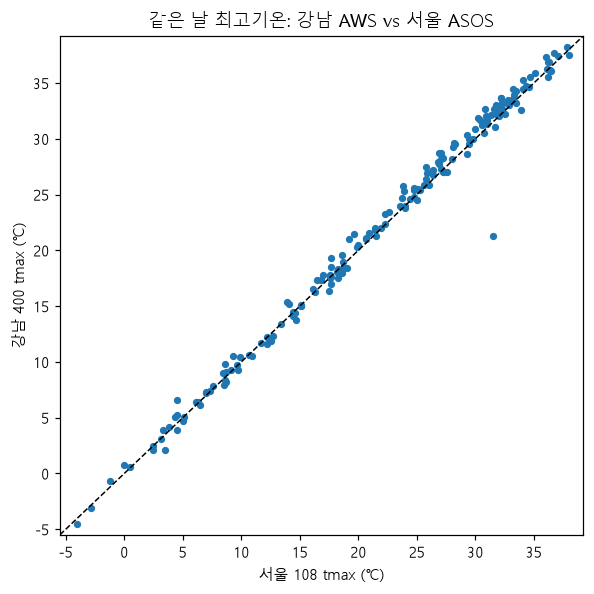

In [5]:
def 관측소표(d25, 변수):
    """날짜 x 관측소 표로 바꾼다."""
    return d25.pivot(index='date', columns='stn_id', values=변수)


tx, tn, rn = 관측소표(d25, 'tmax'), 관측소표(d25, 'tmin'), 관측소표(d25, 'rain')

행 = []
for s in [STN_GN, STN_SEOUL, 401, 403]:
    행.append({
        '관측소': f"{d25.loc[d25['stn_id'].eq(s), 'stn_name'].iat[0]} {s}",
        'tmax 평균': tx[s].mean(),
        '108과 tmax 차이': (tx[s] - tx[STN_SEOUL]).mean(),
        'tmax 상관': tx[s].corr(tx[STN_SEOUL]),
        'tmin 상관': tn[s].corr(tn[STN_SEOUL]),
        'rain 상관': rn[s].corr(rn[STN_SEOUL]),
        '폭염일': int((tx[s] >= THRESH['heat33']).sum()),
        '35℃ 이상': int((tx[s] >= THRESH['heat35']).sum()),
        '열대야': int((tn[s] >= THRESH['tropical']).sum()),
        '호우일': int((rn[s] >= THRESH['rain30']).sum()),
    })
display(pd.DataFrame(행).set_index('관측소').round(3))

g33, s33 = tx[STN_GN] >= THRESH['heat33'], tx[STN_SEOUL] >= THRESH['heat33']
print(f'400만 폭염인 날 {int((g33 & ~s33).sum())}일, 108만 폭염인 날 {int((~g33 & s33).sum())}일')
차 = (tx[STN_GN] - tx[STN_SEOUL])
print(f'tmax 차이(400-108): 평균 {차.mean():+.2f}℃, 7~8월만 {차[차.index.month.isin([7, 8])].mean():+.2f}℃, '
      f'최소 {차.min():+.1f}℃ ({차.idxmin().date()}), 최대 {차.max():+.1f}℃')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(tx[STN_SEOUL], tx[STN_GN], s=14, color=REGION_COLOR['강남'])
lim = [tx[[STN_SEOUL, STN_GN]].min().min() - 1, tx[[STN_SEOUL, STN_GN]].max().max() + 1]
ax.plot(lim, lim, 'k--', lw=1)
ax.set(xlim=lim, ylim=lim, xlabel='서울 108 tmax (℃)', ylabel='강남 400 tmax (℃)',
       title='같은 날 최고기온: 강남 AWS vs 서울 ASOS')
plt.tight_layout(); plt.show()

### 1-3. 강남 AWS 400 자료의 함정 두 가지

In [6]:
# 함정 1: 하루 중 일부 시간만 관측한 날
짧은 = d25.loc[d25['stn_id'].eq(STN_GN) & d25['obs_hours'].lt(24), 'date']
비교 = (d25[d25['date'].isin(짧은) & d25['stn_id'].isin([STN_GN, STN_SEOUL, 401, 403])]
        .pivot_table(index='date', columns='stn_name', values=['tmax', 'tmin', 'rain']))
print('함정 1. 400이 일부 시간만 관측한 날')
display(비교.round(1))

# 함정 2: 하루 강수는 0인데 1시간 최다 강수가 0보다 큰 날 (있을 수 없는 조합)
모순 = d25[d25['stn_id'].eq(STN_GN) & d25['rain'].eq(0) & d25['rain_1h_max'].gt(0)]
행 = []
for _, r in 모순.iterrows():
    시간합 = wx_hourly.loc[wx_hourly['stn_id'].eq(STN_GN) & wx_hourly['datetime'].dt.date.eq(r['date'].date()),
                          'rain'].sum()
    행.append({'date': r['date'].date(), '400 rain': r['rain'], '400 rain_1h_max': r['rain_1h_max'],
               '400 시간자료 합': round(시간합, 1),
               '108 rain': rn.loc[r['date'], STN_SEOUL]})
print('함정 2. 일강수 0인데 1시간 최다 강수 > 0')
display(pd.DataFrame(행))

# 전 기간 전 관측소에서 같은 모순이 몇 날인지
전체모순 = (wx_daily[wx_daily['rain'].eq(0) & wx_daily['rain_1h_max'].gt(0)]
           .groupby(['stn_name', 'stn_id']).size().rename('모순 날 수').sort_values(ascending=False))
display(전체모순.to_frame().T)

함정 1. 400이 일부 시간만 관측한 날


rain                 tmax                    tmin                  
stn_name     강남   서울   서초   송파    강남    서울    서초    송파    강남    서울    서초    송파
date                                                                          
2025-09-10 0.00 0.00 0.00 0.00 21.30 31.50 31.30 31.30 19.40 18.40 18.90 19.30
2025-09-11 0.00 0.00 0.00 0.00 31.10 31.70 30.90 31.00 25.10 19.90 18.30 19.20

함정 2. 일강수 0인데 1시간 최다 강수 > 0


,date,400 rain,400 rain_1h_max,400 시간자료 합,108 rain
0,2025-09-13,0.00,20.00,67.50,63.70
1,2025-10-18,0.00,2.50,10.00,11.20


stn_name,송파,강남,서초,남이섬,남산,서울,춘천
stn_id,403,400,401,675,588,108,101
모순 날 수,20,15,11,8,6,2,2


### 1-4. 춘천 101과 북춘천 93 비교

In [7]:
행 = []
for s in [STN_CC, STN_NCC, 675]:
    행.append({
        '관측소': f"{wx_daily.loc[wx_daily['stn_id'].eq(s), 'stn_name'].iat[0]} {s}",
        'tmax 평균': tx[s].mean(),
        '101과 tmax 차이': (tx[s] - tx[STN_CC]).mean(),
        'tmax 상관': tx[s].corr(tx[STN_CC]),
        'rain 상관': rn[s].corr(rn[STN_CC]),
        '폭염일': int((tx[s] >= THRESH['heat33']).sum()),
        '35℃ 이상': int((tx[s] >= THRESH['heat35']).sum()),
        '호우일': int((rn[s] >= THRESH['rain30']).sum()),
        '한파일': int((tn[s] <= THRESH['cold12']).sum()),
        '자료 시작': wx_daily.loc[wx_daily['stn_id'].eq(s), 'date'].min().date(),
    })
display(pd.DataFrame(행).set_index('관측소').round(3))

c33, n33 = tx[STN_CC] >= THRESH['heat33'], tx[STN_NCC] >= THRESH['heat33']
print(f'101과 93의 폭염 판정이 같은 날: {int((c33 == n33).sum())}일 / 184일')
print('시간자료가 있는 관측소:', sorted(wx_hourly['stn_id'].unique()), '-> 93은 없음')

,tmax 평균,101과 tmax 차이,tmax 상관,rain 상관,폭염일,35℃ 이상,호우일,한파일,자료 시작
관측소,,,,,,,,,
춘천 101,21.53,0.00,1.00,1.00,30,11,18,3,1975-07-01
북춘천 93,21.14,-0.39,1.00,0.96,28,13,14,3,2016-10-01
남이섬 675,20.54,-0.99,1.00,0.93,17,9,15,1,2015-07-01


101과 93의 폭염 판정이 같은 날: 180일 / 184일
시간자료가 있는 관측소: [101, 108, 400, 401, 403, 588, 675] -> 93은 없음


**결정**: 지역 대표 관측소 규칙을 적어 둔다. (기본안: 강남 = 400, 400이 빈칸이거나 믿기 어려운 값이면 108로 채움 / 춘천 = 101)
"믿기 어려운 값"을 무엇으로 정할지도 적는다. (기본안: ① obs_hours < 24 인 날은 그날 전체 변수를 108로 ② rain == 0 이고 rain_1h_max > 0 인 날은 rain만 108로)

- **결정**: 기본안을 그대로 쓴다. 강남 = 400(믿기 어려운 값은 108로 채움), 춘천 = 101.
  믿기 어려운 값은 ① `obs_hours < 24` 인 날 전체 변수, ② `rain == 0` 인데 `rain_1h_max > 0` 인 날의 강수. 2025년 하반기에 해당하는 날은 4일(9/10, 9/11, 9/13, 10/18)이다.
- **이유**: 400은 강남구 안에 있어 지역 대표성이 가장 높지만 9/10, 9/11은 하루 8시간, 7시간만 관측해 한낮이 빠졌고(tmax 21.3℃, 같은 날 108은 31.5℃),
  9/13은 시간자료로 67.5mm가 왔는데 일강수가 0으로 적혀 있다. 그대로 쓰면 **가짜 열대야 1일과 놓친 호우일 1일**이 생긴다.
  춘천은 101과 93이 거의 같게 움직이지만(tmax 상관 0.999, 폭염 판정 180/184일 일치) 101만 1975년부터의 긴 자료와 시간자료가 있다.

### 1장 정리
- **본 것**: 관측소 8곳의 결측(1-1), 강남 400과 서울 108 비교(1-2), 400 자료의 함정 두 가지(1-3), 춘천 101과 북춘천 93 비교(1-4)
- **나온 것**:
  - 일자료에 **빈칸은 0개**지만, 400은 9/10(8시간), 9/11(7시간)만 관측했고 시간자료는 34시간이 비어 있다
  - 400과 108의 **폭염일이 33일 대 25일**로 8일 차이 난다(tmax 차이 평균 +0.32℃, 7~8월은 +0.64℃). 임계값 근처 날이 많아 관측소 선택이 일수를 크게 바꾼다
  - 일강수 0인데 1시간 최다 강수가 0보다 큰 모순이 전 기간 400에 15일, 403에 20일 있다. 2025년에는 9/13(실제 63.7mm)과 10/18
  - 101과 93은 사실상 같지만 93은 2016년 신설이라 평년값을 만들 수 없고 시간자료도 없다. 남이섬 675는 폭염 17일뿐이라 시내 대표로 부적합
- **시사점**:
  - "빈칸이 없다"가 "값이 믿을 만하다"는 뜻이 아니다. **관측시간 수와 변수 간 모순**을 함께 봐야 한다
  - 폭염일 수를 말할 때는 **어느 관측소 기준인지 반드시 밝혀야 한다**(강남 400 기준 33일, 서울 108 기준 25일)

## 2. 지역 일별 날씨 표와 이벤트 라벨
1장에서 정한 규칙으로 **날짜 × 지역(강남, 춘천)** 표를 만들고, `THRESH` 기준으로 이벤트 열(True/False)을 붙인다.
이 표가 07번과 05번에서 카드 매출에 붙는 날씨 표이다. (평년 편차 열은 3장에서 붙인 뒤 저장)

### 2-1. 강남 일별 표 만들기 (400 + 108로 채우기)

In [8]:
VARS = ['tmax', 'tmin', 'tavg', 'rain', 'rain_1h_max', 'hum', 'wind']

gn400 = d25[d25['stn_id'].eq(STN_GN)].set_index('date')
s108 = d25[d25['stn_id'].eq(STN_SEOUL)].set_index('date')

gn = gn400[VARS].copy()
# 1장 결정 1: 하루 중 일부만 관측한 날은 그날 값 전체를 믿지 않는다
gn.loc[gn400['obs_hours'] < 24, VARS] = np.nan
# 1장 결정 2: 강수 0인데 1시간 최다 강수 > 0 인 날은 강수만 믿지 않는다
gn.loc[gn400['rain'].eq(0) & gn400['rain_1h_max'].gt(0), 'rain'] = np.nan

filled = gn.isna().any(axis=1)          # 채우기 '전'에 표시해 둬야 한다
gn = gn.fillna(s108[VARS])              # 날짜가 같은 칸끼리 108 값으로 채움
gn['filled_from_108'] = filled
gn['region'] = '강남'

print(f'{len(gn)}행, 108로 채운 날 {int(filled.sum())}일:', [str(d.date()) for d in gn.index[filled]])
display(gn.loc[filled, ['tmax', 'tmin', 'rain']].round(1))

184행, 108로 채운 날 4일: ['2025-09-10', '2025-09-11', '2025-09-13', '2025-10-18']


,tmax,tmin,rain
date,,,
2025-09-10,31.50,18.40,0.00
2025-09-11,31.70,19.90,0.00
2025-09-13,27.00,20.60,63.70
2025-10-18,18.00,15.80,11.20


### 2-2. 춘천 표를 붙이고 이벤트 라벨 달기

In [9]:
cc = d25[d25['stn_id'].eq(STN_CC)].set_index('date')[VARS].copy()
cc['filled_from_108'] = False
cc['region'] = '춘천'

wx = pd.concat([gn, cc]).reset_index()

wx['heat33'] = wx['tmax'] >= THRESH['heat33']
wx['heat35'] = wx['tmax'] >= THRESH['heat35']
wx['tropical'] = wx['tmin'] >= THRESH['tropical']
wx['rain30'] = wx['rain'] >= THRESH['rain30']
wx['rain80'] = wx['rain'] >= THRESH['rain80']
wx['cold12'] = wx['tmin'] <= THRESH['cold12']

print(f'{len(wx)}행 = 184일 x 2지역')
display(wx.groupby('region')[EVENTS].sum())

극값 = wx.groupby('region').agg(
    최고기온=('tmax', 'max'), 최저기온=('tmin', 'min'), 최다강수=('rain', 'max'))
for r in ['강남', '춘천']:
    g = wx[wx['region'].eq(r)]
    print(f"{r}: 최고 {g['tmax'].max():.1f}℃ ({g.loc[g['tmax'].idxmax(), 'date'].date()}), "
          f"최저 {g['tmin'].min():.1f}℃ ({g.loc[g['tmin'].idxmin(), 'date'].date()}), "
          f"최다강수 {g['rain'].max():.1f}mm ({g.loc[g['rain'].idxmax(), 'date'].date()})")

368행 = 184일 x 2지역


,heat33,heat35,tropical,rain30,rain80,cold12
region,,,,,,
강남,33,15,44,11,1,0
춘천,30,11,5,18,1,3


강남: 최고 38.2℃ (2025-07-08), 최저 -10.6℃ (2025-12-26), 최다강수 112.5mm (2025-07-17)
춘천: 최고 37.1℃ (2025-07-29), 최저 -13.4℃ (2025-12-26), 최다강수 94.7mm (2025-07-20)


### 2-3. 월별 이벤트 일수 표

In [10]:
wx['month'] = wx['date'].dt.month
월별 = wx.groupby(['region', 'month'])[EVENTS].sum()
display(월별)

for e in ['heat33', 'rain30']:
    p = wx.pivot(index='date', columns='region', values=e)
    print(f'{e}: 두 지역 모두 {int(p.all(axis=1).sum())}일, 한 곳이라도 {int(p.any(axis=1).sum())}일')

같은날 = wx.groupby('region').apply(lambda g: int((g['heat33'] & g['rain30']).sum()), include_groups=False)
print('폭염과 호우가 같은 날:', 같은날.to_dict())
print('마지막 폭염일:', wx[wx['heat33']].groupby('region')['date'].max().dt.date.to_dict())

heat33  heat35  tropical  rain30  rain80  cold12
region month                                                  
강남     7          17      12        23       3       1       0
       8          15       3        20       3       0       0
       9           1       0         1       4       0       0
       10          0       0         0       1       0       0
       11          0       0         0       0       0       0
       12          0       0         0       0       0       0
춘천     7          17       9         3       4       1       0
       8          13       2         2       4       0       0
       9           0       0         0       7       0       0
       10          0       0         0       3       0       0
       11          0       0         0       0       0       0
       12          0       0         0       0       0       3

heat33: 두 지역 모두 27일, 한 곳이라도 36일
rain30: 두 지역 모두 8일, 한 곳이라도 21일
폭염과 호우가 같은 날: {'강남': 1, '춘천': 0}
마지막 폭염일: {'강남': datetime.date(2025, 9, 5), '춘천': datetime.date(2025, 8, 29)}


### 2-4. 이벤트 달력 띠 그래프

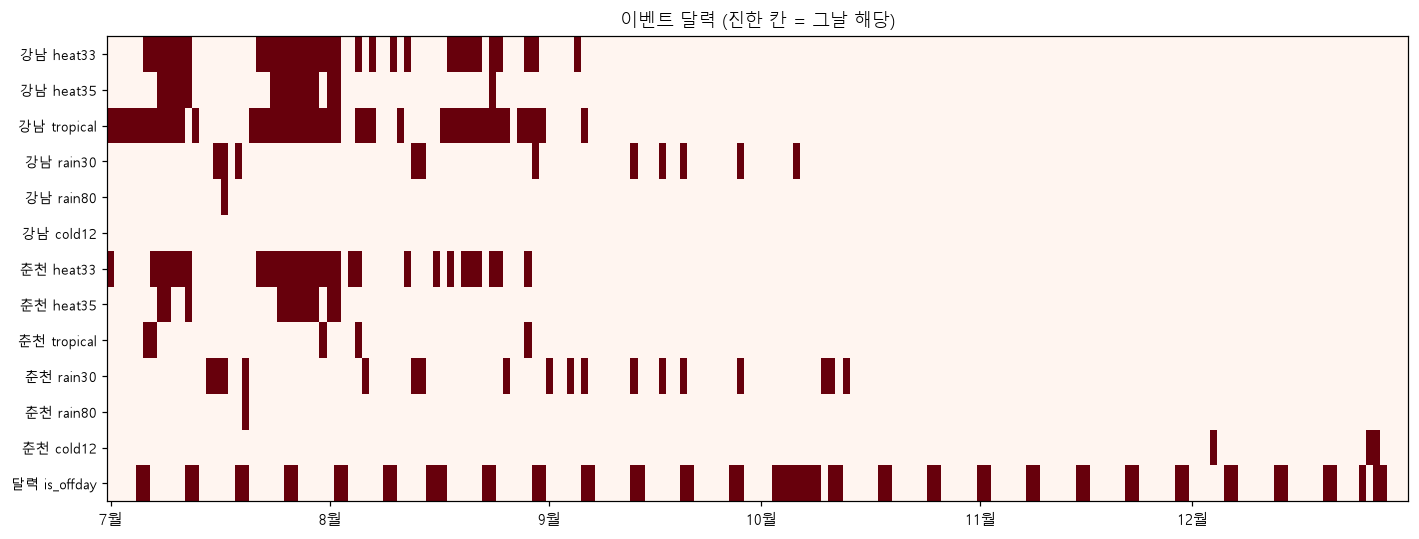

In [11]:
띠 = (wx.set_index(['region', 'date'])[EVENTS].stack().unstack('date')
      .astype(int))                                   # 행 = (지역, 이벤트), 열 = 날짜
쉬는날 = calendar.set_index('date')['is_offday'].reindex(띠.columns).astype(int).to_frame().T
쉬는날.index = pd.MultiIndex.from_tuples([('달력', 'is_offday')])
띠 = pd.concat([띠, 쉬는날])

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(띠.values, aspect='auto', cmap='Reds', interpolation='nearest')
ax.set_yticks(range(len(띠)))
ax.set_yticklabels([f'{a} {b}' for a, b in 띠.index], fontsize=9)
첫날 = [i for i, d in enumerate(띠.columns) if d.day == 1]
ax.set_xticks(첫날)
ax.set_xticklabels([f'{띠.columns[i].month}월' for i in 첫날])
ax.set_title('이벤트 달력 (진한 칸 = 그날 해당)')
plt.tight_layout(); plt.show()

### 2-5. 기온과 강수 추이

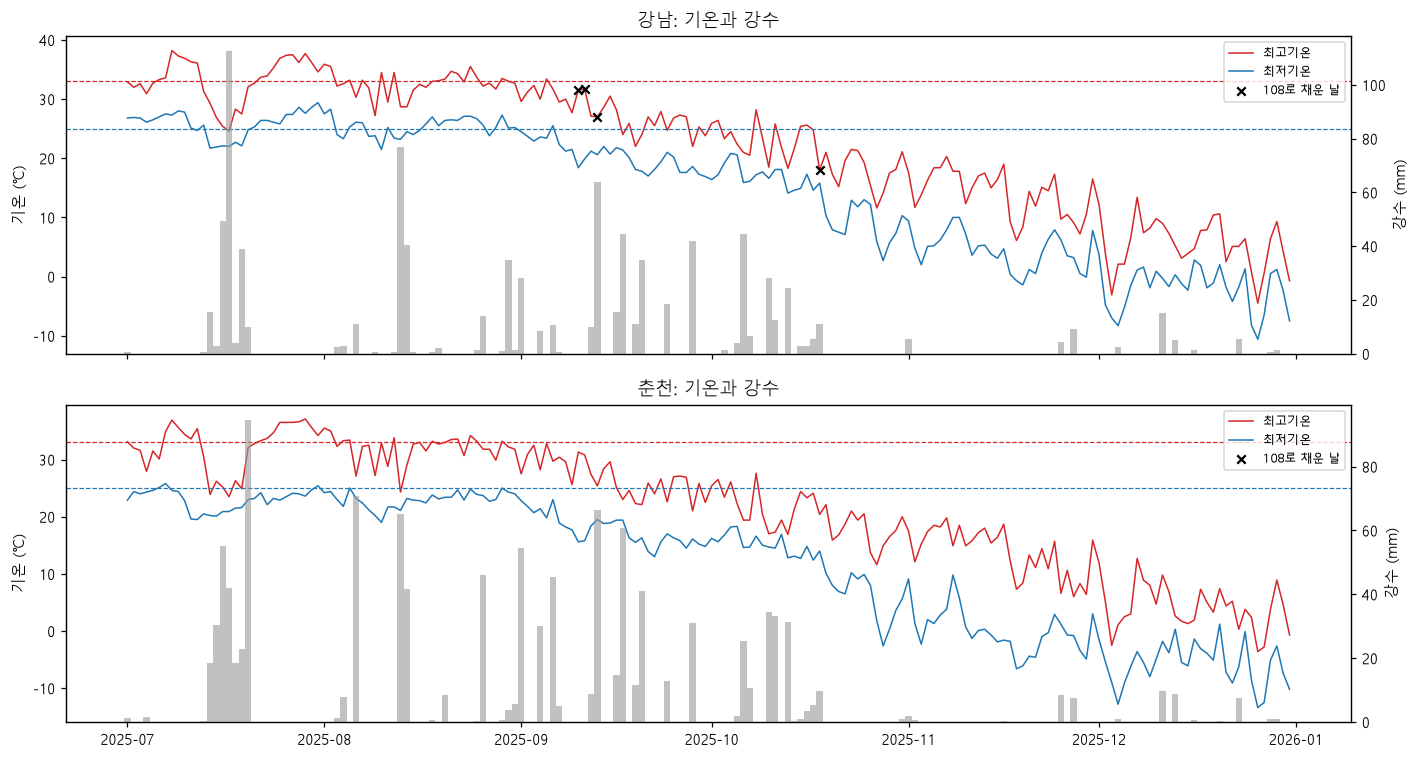

In [12]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 7))
for ax, r in zip(axes, ['강남', '춘천']):
    g = wx[wx['region'].eq(r)].set_index('date')
    ax.plot(g.index, g['tmax'], color='#d62728', lw=1, label='최고기온')
    ax.plot(g.index, g['tmin'], color='#1f77b4', lw=1, label='최저기온')
    ax.axhline(THRESH['heat33'], ls='--', color='#d62728', lw=0.8)
    ax.axhline(THRESH['tropical'], ls='--', color='#1f77b4', lw=0.8)
    ax.scatter(g.index[g['filled_from_108']], g.loc[g['filled_from_108'], 'tmax'],
               marker='x', color='k', s=30, zorder=5, label='108로 채운 날')
    ax2 = ax.twinx()
    ax2.bar(g.index, g['rain'], color='0.6', width=1.0, alpha=0.6)
    ax2.set_ylabel('강수 (mm)')
    ax.set(ylabel='기온 (℃)', title=f'{r}: 기온과 강수')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### 2장 정리
- **본 것**: 규칙대로 채운 강남 표(2-1), 지역 일별 표와 이벤트 라벨(2-2), 월별 이벤트 일수(2-3), 달력 띠와 기온 추이(2-4, 2-5)
- **나온 것**:
  - 368행(184일 x 2지역). 강남 폭염 33일, 35℃ 이상 15일, **열대야 44일**, 호우 11일 / 춘천 폭염 30일, 35℃ 이상 11일, **열대야 5일**, 호우 18일, 한파 3일
  - 폭염은 **7~8월에만** 있고(마지막 폭염 강남 9/5, 춘천 8/29), 호우는 7~10월에 흩어져 있다. 11~12월은 이벤트가 거의 없다
  - 두 지역이 같은 날 폭염인 날이 27일(한 곳이라도 36일), 같은 날 호우인 날은 8일(한 곳이라도 21일)
  - 폭염과 호우가 같은 날인 경우는 강남 1일, 춘천 0일
- **시사점**:
  - **열대야가 44일 대 5일**로 갈린다. 도시 열섬과 분지 지형의 차이로 보이며, 열대야를 두 지역 공통 라벨로 쓰면 춘천 쪽은 표본이 5일뿐이라 해석이 어렵다
  - 11~12월은 이벤트가 없어 **"평상시" 기준 구간**으로 쓸 수 있다
  - 폭염과 호우가 거의 겹치지 않아 **두 충격을 따로 볼 수 있다**

## 3. 평년값과 편차 (2025년이 얼마나 이상했나)
"33℃"는 7월 말에는 흔한 기온이지만 9월에는 이상한 기온이다. **그 날짜의 평소 기온(평년값)** 과 비교한 편차(anomaly)가 있으면 계절을 빼고 "이상한 정도"를 볼 수 있다.
평년값은 **30년(1991~2020) 평균**으로 만든다. 강남 AWS는 2015년부터라 30년이 안 되므로 **강남의 평년값은 서울 108** 로 만든다.

### 3-1. 날짜별 평년값 만들기

In [13]:
lo, hi = NORMAL_YEARS
과거 = wx_daily[wx_daily['stn_id'].isin([STN_SEOUL, STN_CC]) & wx_daily['date'].dt.year.between(lo, hi)]
print('1991~2020년 행 수:', 과거.groupby('stn_id').size().to_dict(),
      '| tmax 빈칸:', 과거.groupby('stn_id')['tmax'].apply(lambda s: int(s.isna().sum())).to_dict())

일별평균 = (과거.groupby(['stn_id', 과거['date'].dt.month.rename('month'), 과거['date'].dt.day.rename('day')])
           [['tmax', 'tmin']].mean())

# 하루 평균은 30개 값이라 울퉁불퉁하다. 앞뒤 3일씩 묶어(7일 이동평균) 매끈하게 만든다
평년 = (일별평균.groupby(level='stn_id')
        .transform(lambda s: s.rolling(7, center=True, min_periods=1).mean())
        .rename(columns={'tmax': 'tmax_normal', 'tmin': 'tmin_normal'})
        .reset_index())

display(평년[평년[['month', 'day']].apply(tuple, axis=1).isin([(7, 1), (8, 15), (12, 31)])].round(2))

1991~2020년 행 수: {101: 5520, 108: 5520} | tmax 빈칸: {101: 0, 108: 1}


,stn_id,month,day,tmax_normal,tmin_normal
0,101,7,1,28.50,20.31
45,101,8,15,30.48,21.79
183,101,12,31,1.58,-8.99
184,108,7,1,27.76,21.01
229,108,8,15,30.45,23.48
367,108,12,31,2.03,-5.39


### 3-2. 2025년 편차 계산과 그래프

184일 평균 편차


,tmax_anom,tmin_anom
region,,
강남,2.09,2.33
춘천,1.66,1.70


월별 tmax 편차


month,7,8,9,10,11,12
region,,,,,,
강남,4.17,2.60,1.57,0.71,2.25,1.20
춘천,2.87,2.04,1.28,0.45,2.67,0.67


월별 tmin 편차


month,7,8,9,10,11,12
region,,,,,,
강남,3.53,2.41,2.77,2.93,0.91,1.36
춘천,1.69,1.75,2.37,3.77,-0.32,0.89


강남: tmax 편차 +5℃ 이상 32일, 최대 +9.49 (2025-07-08), 폭염일 평균 편차 +5.41
춘천: tmax 편차 +5℃ 이상 26일, 최대 +8.98 (2025-11-30), 폭염일 평균 편차 +4.86


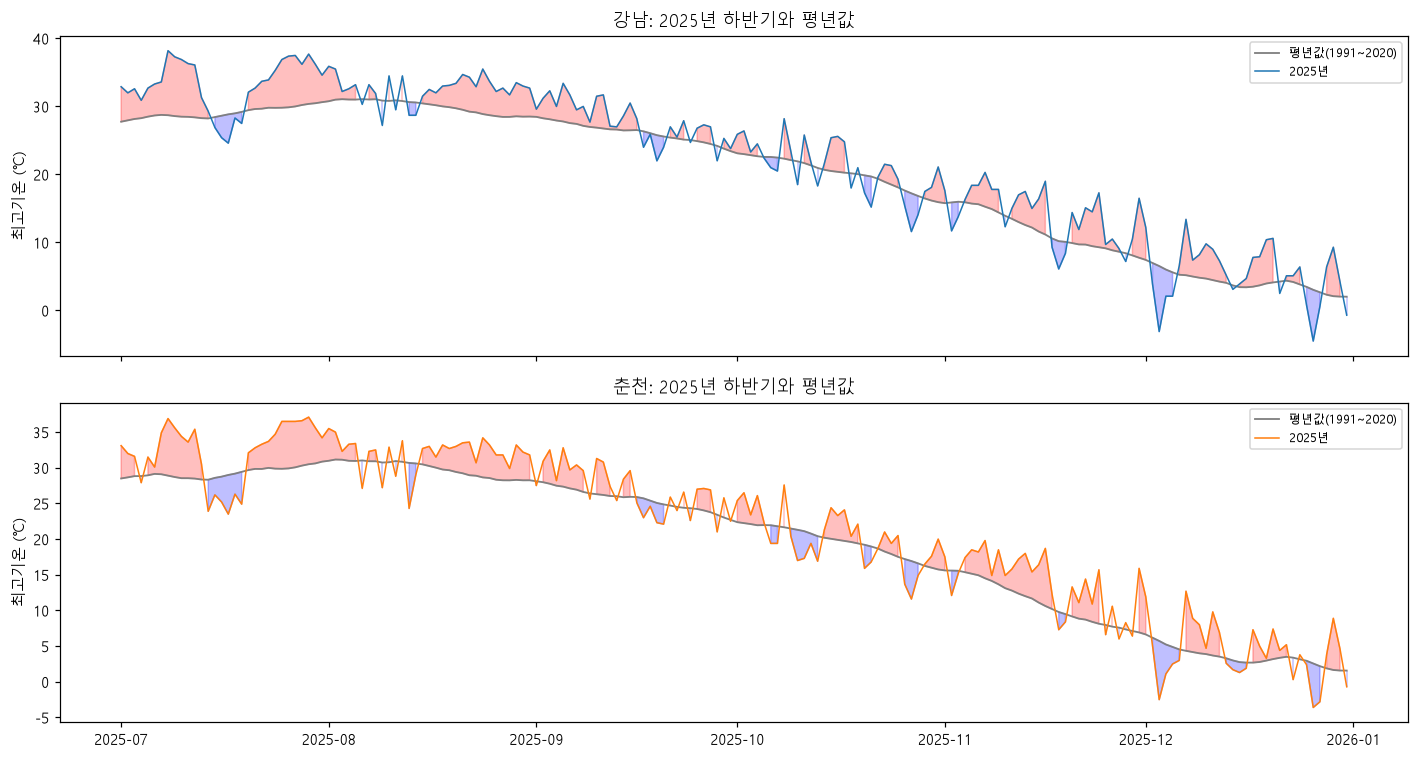

In [14]:
REGION_STN = {'강남': STN_SEOUL, '춘천': STN_CC}      # 평년값을 만들 긴 자료가 있는 관측소
wx['day'] = wx['date'].dt.day
wx['normal_stn'] = wx['region'].map(REGION_STN)
wx = wx.merge(평년, left_on=['normal_stn', 'month', 'day'], right_on=['stn_id', 'month', 'day'], how='left') \
       .drop(columns=['stn_id', 'normal_stn'])

wx['tmax_anom'] = wx['tmax'] - wx['tmax_normal']
wx['tmin_anom'] = wx['tmin'] - wx['tmin_normal']

print('184일 평균 편차'); display(wx.groupby('region')[['tmax_anom', 'tmin_anom']].mean().round(2))
print('월별 tmax 편차'); display(wx.pivot_table(index='region', columns='month', values='tmax_anom').round(2))
print('월별 tmin 편차'); display(wx.pivot_table(index='region', columns='month', values='tmin_anom').round(2))

for r in ['강남', '춘천']:
    g = wx[wx['region'].eq(r)]
    print(f"{r}: tmax 편차 +5℃ 이상 {int((g['tmax_anom'] >= 5).sum())}일, "
          f"최대 {g['tmax_anom'].max():+.2f} ({g.loc[g['tmax_anom'].idxmax(), 'date'].date()}), "
          f"폭염일 평균 편차 {g.loc[g['heat33'], 'tmax_anom'].mean():+.2f}")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 7))
for ax, r in zip(axes, ['강남', '춘천']):
    g = wx[wx['region'].eq(r)].set_index('date')
    ax.plot(g.index, g['tmax_normal'], color='0.5', lw=1.2, label='평년값(1991~2020)')
    ax.plot(g.index, g['tmax'], color=REGION_COLOR[r], lw=1, label='2025년')
    ax.fill_between(g.index, g['tmax_normal'], g['tmax'], where=g['tmax'] >= g['tmax_normal'],
                    color='red', alpha=0.25)
    ax.fill_between(g.index, g['tmax_normal'], g['tmax'], where=g['tmax'] < g['tmax_normal'],
                    color='blue', alpha=0.25)
    ax.set(ylabel='최고기온 (℃)', title=f'{r}: 2025년 하반기와 평년값')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### 3-3. 강남 편차의 함정 (관측소가 다름)

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
tmax 차이(400-108),-0.54,-0.33,-0.53,-0.46,0.11,0.59,0.63,0.42,0.57,0.35,0.32
tmin 차이(400-108),1.28,1.31,1.05,1.30,0.01,0.19,0.37,0.25,0.16,0.20,0.28


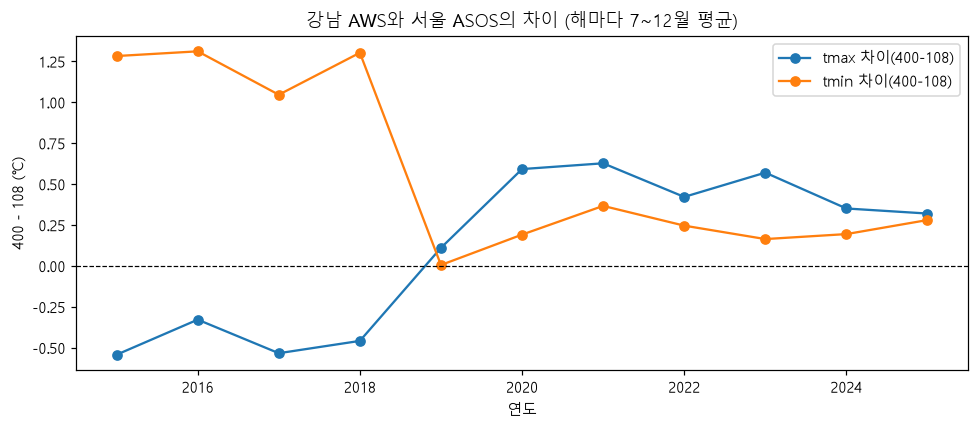

In [15]:
둘다 = wx_daily[wx_daily['stn_id'].isin([STN_GN, STN_SEOUL]) & wx_daily['date'].dt.year.ge(2015)]
연도별 = (둘다.pivot_table(index=둘다['date'].dt.year.rename('year'), columns='stn_id',
                          values=['tmax', 'tmin'], aggfunc='mean'))
차이 = pd.DataFrame({'tmax 차이(400-108)': 연도별[('tmax', STN_GN)] - 연도별[('tmax', STN_SEOUL)],
                    'tmin 차이(400-108)': 연도별[('tmin', STN_GN)] - 연도별[('tmin', STN_SEOUL)]})
display(차이.round(2).T)

fig, ax = plt.subplots(figsize=(9, 4))
차이.plot(ax=ax, marker='o')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set(xlabel='연도', ylabel='400 - 108 (℃)', title='강남 AWS와 서울 ASOS의 차이 (해마다 7~12월 평균)')
plt.tight_layout(); plt.show()

### 3-4. wx_region_daily 저장

In [16]:
COLS = ['date', 'region', 'tmax', 'tmin', 'tavg', 'rain', 'rain_1h_max', 'hum', 'wind', 'filled_from_108',
        'heat33', 'heat35', 'tropical', 'rain30', 'rain80', 'cold12',
        'tmax_normal', 'tmax_anom', 'tmin_normal', 'tmin_anom']

wx_region_daily = wx[COLS].sort_values(['region', 'date']).reset_index(drop=True)
print('모양:', wx_region_daily.shape, '| 빈칸:', int(wx_region_daily.isna().sum().sum()),
      '| filled_from_108:', int(wx_region_daily['filled_from_108'].sum()))
wx_region_daily.to_parquet(OUT / 'wx_region_daily.parquet', index=False)
display(wx_region_daily.head(3))

모양: (368, 20) | 빈칸: 0 | filled_from_108: 4


,date,region,tmax,tmin,tavg,rain,rain_1h_max,hum,wind,filled_from_108,heat33,heat35,tropical,rain30,rain80,cold12,tmax_normal,tmax_anom,tmin_normal,tmin_anom
0,2025-07-01,강남,32.90,26.80,29.10,0.50,0.50,74.90,1.60,False,False,False,True,False,False,False,27.76,5.14,21.01,5.79
1,2025-07-02,강남,32.00,26.90,29.20,0.00,0.00,71.20,1.40,False,False,False,True,False,False,False,27.96,4.04,20.98,5.92
2,2025-07-03,강남,32.60,26.80,28.90,0.00,0.00,70.80,1.50,False,False,False,True,False,False,False,28.16,4.44,21.06,5.74


### 3장 정리
- **본 것**: 30년 평년값 만들기(3-1), 2025년 편차(3-2), 강남 편차에 섞인 관측소 차이(3-3), 저장(3-4)
- **나온 것**:
  - 184일 평균 편차는 tmax 강남 **+2.09℃**, 춘천 **+1.66℃** / tmin 강남 +2.33, 춘천 +1.70
  - 월별로는 **7월이 가장 이상**했다(tmax 강남 +4.17, 춘천 +2.87). 10월은 tmax 편차가 작지만(+0.71, +0.45) tmin 편차는 크다(+2.93, +3.77)
  - 폭염일의 평균 편차는 강남 +5.41, 춘천 +4.86. 가장 큰 편차는 강남 7/8 +9.49, 춘천 11/30 +8.98
  - 400과 108의 차이가 2018년과 2019년 사이에 계단처럼 바뀐다(tmax -0.5 안팎 → +0.3~0.6, tmin +1.2 안팎 → +0.2~0.4)
- **시사점**:
  - 강남의 편차는 실제값(400)과 평년값(108)의 관측소가 달라서 **약 0.3℃가 관측소 차이일 수 있다**. 두 지역 편차를 나란히 비교할 때 기억할 것
  - > [추론] 2019년 전후의 계단 변화는 관측소 이전이나 장비 교체로 보인다. 기상청 지점 정보로 확인이 필요하다

## 4. 장기 비교 (1975~2025년)
3장은 "평소와 비교"였고, 이 장은 **50년 동안 몇 번째인가** 를 본다. 발표 자료에서 "2025년 여름은 관측 이래 몇 번째로 더웠다"는 근거가 된다.
긴 자료는 108과 101에만 있으므로 **강남도 108로** 센다. (400으로 센 33일과 다름에 주의)
자료가 **매년 7~12월만** 있어서 6월 폭염은 세지 못한다는 점도 기억한다.

### 4-1. 연도별 폭염일 수와 2025년 순위

year,2018,2019,2020,2021,2022,2023,2024,2025
stn_id,,,,,,,,
101,32,15,4,21,12,20,19,30
108,35,14,2,18,10,17,29,25


서울 108: 2025년 25일, 51년 중 4위 (상위 3개 [(2018, 35), (2024, 29), (1994, 27)])
춘천 101: 2025년 30일, 51년 중 2위 (상위 3개 [(2018, 32), (2025, 30), (1994, 27)])


,1975~1990,1991~2020,2011~2024
stn_id,,,
101,7.60,9.80,13.70
108,5.90,8.10,13.90


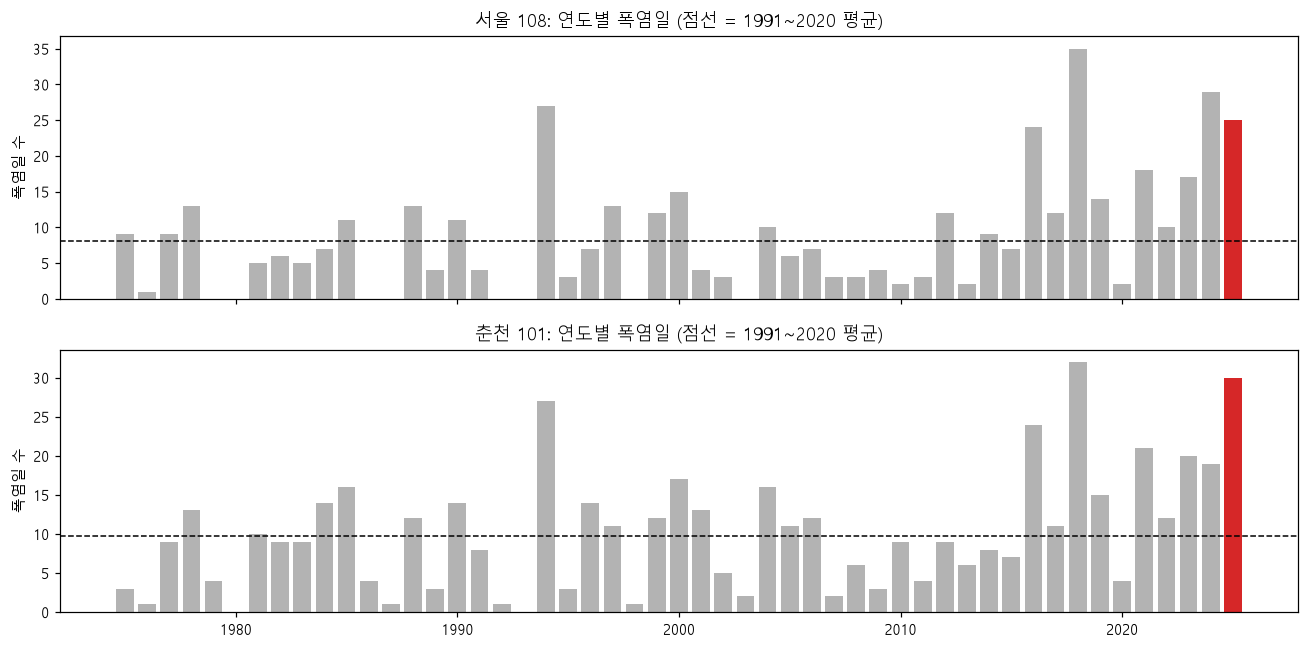

In [17]:
긴자료 = wx_daily[wx_daily['stn_id'].isin([STN_SEOUL, STN_CC])].copy()
긴자료['year'] = 긴자료['date'].dt.year

폭염연도 = (긴자료.groupby(['stn_id', 'year'])['tmax']
           .apply(lambda s: int((s >= THRESH['heat33']).sum())).unstack('stn_id'))
display(폭염연도.tail(8).T)

for s, 이름 in [(STN_SEOUL, '서울 108'), (STN_CC, '춘천 101')]:
    순위 = 폭염연도[s].rank(ascending=False, method='min')[2025]
    상위 = 폭염연도[s].nlargest(3)
    print(f'{이름}: 2025년 {폭염연도.loc[2025, s]}일, {len(폭염연도)}년 중 {int(순위)}위 '
          f'(상위 3개 {[(y, int(v)) for y, v in 상위.items()]})')

기간 = {'1975~1990': (1975, 1990), '1991~2020': NORMAL_YEARS, '2011~2024': (2011, 2024)}
display(pd.DataFrame({k: 폭염연도.loc[a:b].mean() for k, (a, b) in 기간.items()}).round(1))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (s, 이름) in zip(axes, [(STN_SEOUL, '서울 108'), (STN_CC, '춘천 101')]):
    색 = ['#d62728' if y == 2025 else '0.7' for y in 폭염연도.index]
    ax.bar(폭염연도.index, 폭염연도[s], color=색)
    ax.axhline(폭염연도.loc[NORMAL_YEARS[0]:NORMAL_YEARS[1], s].mean(), ls='--', color='k', lw=1)
    ax.set(ylabel='폭염일 수', title=f'{이름}: 연도별 폭염일 (점선 = 1991~2020 평균)')
plt.tight_layout(); plt.show()

### 4-2. 7~8월 평균 최고기온

서울 108: 2025년 32.27℃, 2위 (상위 3개 [(2018, 32.72), (2025, 32.27), (1994, 32.25)]), 평년 29.52℃, 추세 +0.38℃/10년
춘천 101: 2025년 32.04℃, 1위 (상위 3개 [(2025, 32.04), (2018, 31.92), (1994, 31.76)]), 평년 29.58℃, 추세 +0.32℃/10년


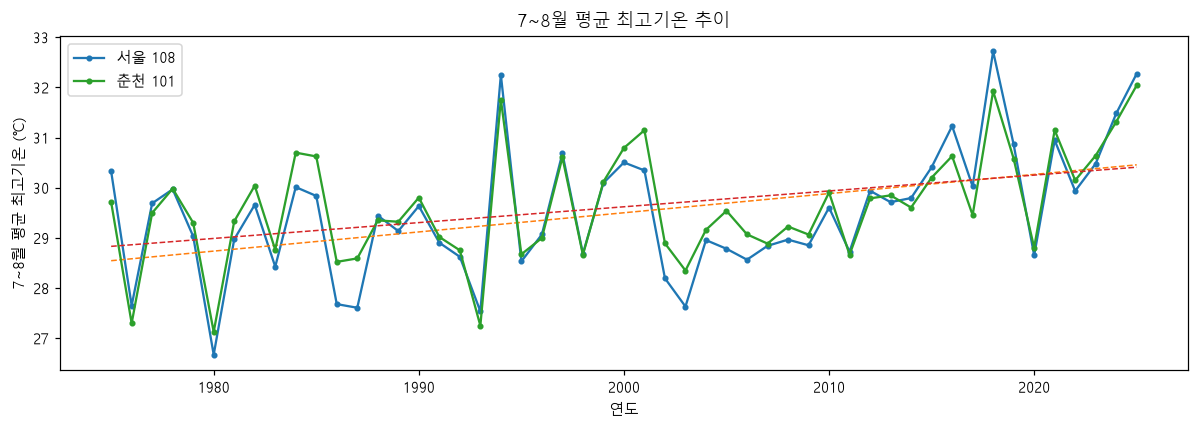

In [18]:
여름 = 긴자료[긴자료['date'].dt.month.isin([7, 8])]
여름tmax = 여름.groupby(['stn_id', 'year'])['tmax'].mean().unstack('stn_id')

fig, ax = plt.subplots(figsize=(11, 4))
for s, 이름 in [(STN_SEOUL, '서울 108'), (STN_CC, '춘천 101')]:
    ax.plot(여름tmax.index, 여름tmax[s], marker='o', ms=3, label=이름)
    기울기 = np.polyfit(여름tmax.index, 여름tmax[s], 1)[0]
    ax.plot(여름tmax.index, np.poly1d(np.polyfit(여름tmax.index, 여름tmax[s], 1))(여름tmax.index),
            ls='--', lw=1)
    순위 = 여름tmax[s].rank(ascending=False, method='min')[2025]
    print(f'{이름}: 2025년 {여름tmax.loc[2025, s]:.2f}℃, {int(순위)}위 '
          f'(상위 3개 {[(y, round(v, 2)) for y, v in 여름tmax[s].nlargest(3).items()]}), '
          f'평년 {여름tmax.loc[NORMAL_YEARS[0]:NORMAL_YEARS[1], s].mean():.2f}℃, 추세 {기울기 * 10:+.2f}℃/10년')
ax.set(xlabel='연도', ylabel='7~8월 평균 최고기온 (℃)', title='7~8월 평균 최고기온 추이')
ax.legend(); plt.tight_layout(); plt.show()

### 4-3. 연도별 열대야 수와 시간자료 주의점

In [19]:
열대야연도 = (긴자료.groupby(['stn_id', 'year'])['tmin']
             .apply(lambda s: int((s >= THRESH['tropical']).sum())).unstack('stn_id'))
for s, 이름 in [(STN_SEOUL, '서울 108'), (STN_CC, '춘천 101')]:
    순위 = 열대야연도[s].rank(ascending=False, method='min')[2025]
    print(f'{이름}: 2025년 열대야 {열대야연도.loc[2025, s]}일, {int(순위)}위 '
          f'(상위 3개 {[(y, int(v)) for y, v in 열대야연도[s].nlargest(3).items()]})')

# 시간자료로 장기 비교를 하면 안 되는 이유: 옛날에는 3시간 간격 관측이라 시각이 비어 있다
h = wx_hourly[wx_hourly['stn_id'].isin([STN_SEOUL, STN_CC])]
빈칸비율 = (h.groupby([h['stn_id'], (h['datetime'].dt.year // 10 * 10).rename('연대')])['temp']
           .apply(lambda s: s.isna().mean()).unstack('stn_id'))
print('\n시간자료 기온 빈칸 비율'); display((빈칸비율 * 100).round(1))

서울 108: 2025년 열대야 44일, 1위 (상위 3개 [(2025, 44), (2024, 42), (1994, 34)])
춘천 101: 2025년 열대야 5일, 9위 (상위 3개 [(2018, 19), (2024, 18), (2022, 12)])

시간자료 기온 빈칸 비율


stn_id,101,108
연대,,
1970,66.70,12.50
1980,21.50,9.80
1990,8.70,7.20
2000,0.00,0.00
2010,0.00,0.00
2020,0.20,0.00


### 4장 정리
- **본 것**: 연도별 폭염일과 2025년 순위(4-1), 7~8월 평균 최고기온(4-2), 열대야 순위와 시간자료의 한계(4-3)
- **나온 것**:
  - 폭염일: 서울 108 **25일로 51년 중 4위**(1위 2018년 35일), 춘천 101 **30일로 2위**(1위 2018년 32일)
  - 평균 폭염일이 계단처럼 올라간다. 108은 1975~1990년 5.9일 → 1991~2020년 8.1일 → 2011~2024년 13.9일
  - 7~8월 평균 최고기온은 108이 32.27℃로 2위, **101은 32.04℃로 관측 이래 1위**. 추세는 +0.38 / +0.32℃/10년
  - 열대야는 108이 44일로 **1위**, 101은 5일로 9위
  - 시간자료는 1970년대 빈칸이 101 66.7%, 108 12.5%라 **시간 지표의 장기 비교는 2000년 이후만 가능**하다
- **시사점**:
  - "2025년 여름은 관측 이래 가장 더웠다"는 **춘천에 대해서만** 쓸 수 있는 문장이다(7~8월 평균 기준). 서울은 2018년이 더 더웠다
  - 자료가 매년 7~12월만 있어 **6월 폭염은 세지 못한다**. 순위를 말할 때 이 범위를 밝혀야 한다

## 5. 시간대별 날씨 (wx_region_slot)
카드 데이터의 시간대는 `00_05`, `06_11`, `12_17`, `18_23` 4개이다. 같은 칸에 맞춰 **시간대별 기온과 강수**를 만들면
"폭염인 날 12~17시 매출만 빠지는가" 같은 질문(탐색 Q5)을 볼 수 있다.
시간자료도 일자료와 같은 규칙: 강남 = 400(빈 시각은 108로), 춘천 = 101.

### 5-1. 지역별 시간자료 만들기

In [20]:
시각목록 = pd.date_range(START, END + pd.Timedelta(hours=23), freq='h')
print('시각 수:', len(시각목록))


def 시간표(stn):
    """관측소 하나의 시간자료를 분석 기간 전체 시각에 맞춰 편다 (없는 시각은 빈칸 행)."""
    t = wx_hourly[wx_hourly['stn_id'].eq(stn)].set_index('datetime')[['temp', 'rain']]
    return t.reindex(시각목록)


h400, h108, h101 = 시간표(STN_GN), 시간표(STN_SEOUL), 시간표(STN_CC)

hg = h400.copy()
빈시각 = hg['temp'].isna()
hg.loc[빈시각, ['temp', 'rain']] = h108.loc[빈시각, ['temp', 'rain']]     # 400이 빈 시각은 108로
hg['region'] = '강남'
hc = h101.copy()
hc['region'] = '춘천'

wxh = pd.concat([hg, hc]).rename_axis('datetime').reset_index()
wxh['date'] = wxh['datetime'].dt.normalize()
wxh['hour'] = wxh['datetime'].dt.hour

print(f'{len(wxh):,}행 (지역마다 {len(시각목록):,}행)')
print(f'강남: 108로 채운 시각 {int(빈시각.sum())}시간', [str(d) for d in h400.index[빈시각][:2]], '...')
print('춘천 기온 빈칸:', wxh.loc[wxh['region'].eq('춘천'), 'temp'].isna().sum(), '시간',
      [str(d) for d in wxh.loc[wxh['region'].eq('춘천') & wxh['temp'].isna(), 'datetime']])

시각 수: 4416
8,832행 (지역마다 4,416행)
강남: 108로 채운 시각 34시간 ['2025-09-10 08:00:00', '2025-09-10 09:00:00'] ...
춘천 기온 빈칸: 1 시간 ['2025-12-16 23:00:00']


### 5-2. 일자료와 시간자료가 같은 말을 하는지 확인

In [21]:
시간요약 = (wxh.groupby(['date', 'region'])
           .agg(시간_최고=('temp', 'max'), 시간_강수합=('rain', 'sum'),
                시간_33이상=('temp', lambda s: int((s >= THRESH['heat33']).sum())))
           .reset_index())
비교 = wx.merge(시간요약, on=['date', 'region'])
비교['tmax차'] = 비교['tmax'] - 비교['시간_최고']
비교['rain차'] = 비교['rain'] - 비교['시간_강수합']

print('tmax - 시간자료 최댓값'); display(비교.groupby('region')['tmax차'].describe().round(2))
이상 = 비교[비교['heat33'] & 비교['시간_33이상'].eq(0)]
print('폭염일인데 33℃ 이상 시각이 0개인 날:', 이상.groupby('region').size().to_dict())
display(이상[['date', 'region', 'tmax', '시간_최고']])
print('강수 차이가 5mm 넘는 날')
display(비교.loc[비교['rain차'].abs() > 5, ['date', 'region', 'rain', '시간_강수합', 'rain차']])

tmax - 시간자료 최댓값


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
강남,184.00,-0.02,0.14,-1.30,0.00,0.00,0.00,0.30
춘천,184.00,0.24,0.21,0.00,0.10,0.20,0.30,1.10


폭염일인데 33℃ 이상 시각이 0개인 날: {'춘천': 6}


,date,region,tmax,시간_최고
184,2025-07-01,춘천,33.10,32.50
218,2025-08-04,춘천,33.30,32.90
230,2025-08-16,춘천,33.00,32.60
232,2025-08-18,춘천,33.20,32.50
234,2025-08-20,춘천,33.00,32.90
239,2025-08-25,춘천,33.20,32.20


강수 차이가 5mm 넘는 날


,date,region,rain,시간_강수합,rain차
257,2025-09-12,춘천,8.70,2.80,5.90
258,2025-09-13,춘천,66.40,72.30,-5.90


### 5-3. 시간대별로 묶어서 wx_region_slot 저장

In [22]:
wxh['time_gb'] = pd.cut(wxh['hour'], bins=[-1, 5, 11, 17, 23],
                        labels=['00_05', '06_11', '12_17', '18_23']).astype(str)

wx_region_slot = (wxh.groupby(['date', 'region', 'time_gb'], as_index=False)
                  .agg(temp_max=('temp', 'max'), temp_mean=('temp', 'mean'),
                       rain_sum=('rain', 'sum'),
                       hours_ge33=('temp', lambda s: int((s >= THRESH['heat33']).sum()))))

print('모양:', wx_region_slot.shape, '| 빈칸:', int(wx_region_slot.isna().sum().sum()))
display(wx_region_slot.pivot_table(index='region', columns='time_gb', values='hours_ge33', aggfunc='sum'))
합 = wx_region_slot.groupby('region')['hours_ge33'].sum()
print('33℃ 이상 시간 합계:', 합.to_dict(),
      f"| 그중 12_17 비중 {wx_region_slot.loc[wx_region_slot['time_gb'].eq('12_17'), 'hours_ge33'].sum() / 합.sum():.0%}")

폭염슬롯 = wx_region_slot.merge(wx[['date', 'region', 'heat33']], on=['date', 'region'])
하루 = 폭염슬롯[폭염슬롯['heat33']].groupby(['region', 'date'])['hours_ge33'].sum()
print('폭염일 하루 평균 33℃ 이상 시간:', 하루.groupby('region').mean().round(1).to_dict(),
      '| 하루 최대:', 하루.groupby('region').max().to_dict())

wx_region_slot.to_parquet(OUT / 'wx_region_slot.parquet', index=False)

모양: (1472, 7) | 빈칸: 0


time_gb,00_05,06_11,12_17,18_23
region,,,,
강남,0,18,139,35
춘천,0,0,93,18


33℃ 이상 시간 합계: {'강남': 192, '춘천': 111} | 그중 12_17 비중 77%
폭염일 하루 평균 33℃ 이상 시간: {'강남': 5.8, '춘천': 3.7} | 하루 최대: {'강남': 12, '춘천': 8}


### 5-4. 폭염일의 하루 기온 모양

time_gb        00_05  06_11  12_17  18_23
region heat33                            
강남     False   25.60  26.60  29.40  27.30
       True    27.60  29.40  34.10  31.00
춘천     False   23.40  24.70  28.20  25.90
       True    24.50  26.70  33.20  29.10

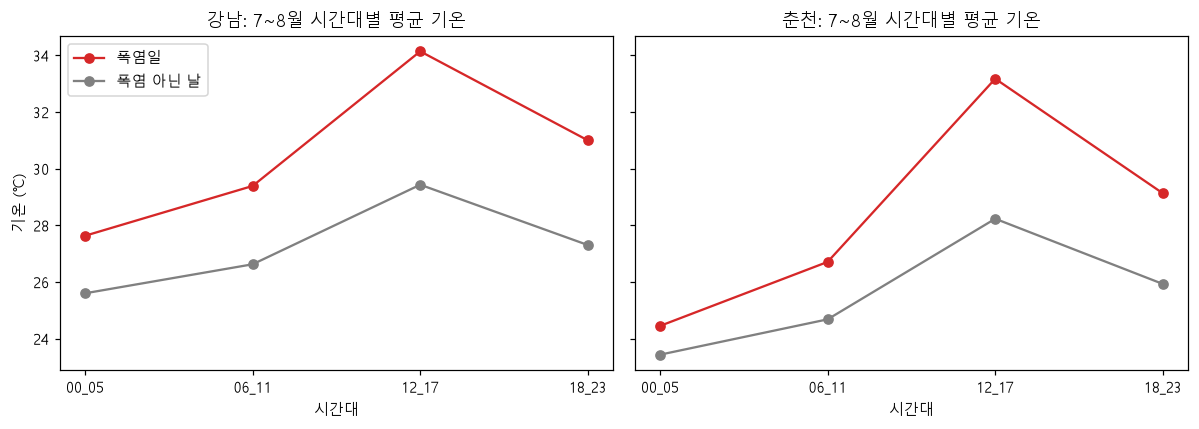

In [23]:
여름슬롯 = 폭염슬롯[폭염슬롯['date'].dt.month.isin([7, 8])]
모양 = 여름슬롯.pivot_table(index=['region', 'heat33'], columns='time_gb', values='temp_mean')
display(모양.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
슬롯순서 = ['00_05', '06_11', '12_17', '18_23']
for ax, r in zip(axes, ['강남', '춘천']):
    for 폭염, 색, 라벨 in [(True, '#d62728', '폭염일'), (False, '0.5', '폭염 아닌 날')]:
        ax.plot(슬롯순서, 모양.loc[(r, 폭염), 슬롯순서], marker='o', color=색, label=라벨)
    ax.set(title=f'{r}: 7~8월 시간대별 평균 기온', xlabel='시간대')
axes[0].set_ylabel('기온 (℃)'); axes[0].legend()
plt.tight_layout(); plt.show()

### 5장 정리
- **본 것**: 시간자료를 지역 단위로 만들기(5-1), 일자료와 대조(5-2), 시간대 표 저장(5-3), 폭염일의 하루 기온 모양(5-4)
- **나온 것**:
  - 1,472행(184일 x 2지역 x 4시간대), 빈칸 없음. 강남은 400의 빈 34시간을 108로 채웠다
  - 일최고기온과 시간자료 최댓값의 차이는 강남 -0.02℃, 춘천 +0.24℃(최대 +1.1). **춘천은 폭염일인데 33℃ 이상 시각이 0개인 날이 6일** 있다
  - 33℃ 이상 시간은 강남 192시간, 춘천 111시간이고 **그중 77%가 12~17시**. 00~05시는 두 지역 모두 0시간
  - 폭염일의 시간대 평균 기온은 강남 12_17이 34.1℃(폭염 아닌 날 29.4℃)로 차이가 가장 크고, **18~23시에도 3℃ 넘게 덥다**
- **시사점**:
  - 일최고기온은 순간값, 시간자료는 정각값이라 **두 기준을 섞어 쓰면 폭염일 수가 달라진다**. 주 라벨은 일 기준(heat33)으로 고정한다
  - 저녁 시간대도 3℃ 이상 더우므로 **저녁 장사(음식점, 주점)도 영향을 받을 수 있다**. 05번에서 시간대별로 나눠 볼 근거가 된다

## 6. 이벤트 구간 (wx_events)
05번의 event study는 "폭염이 시작된 날(t=0)" 기준으로 앞뒤 며칠을 본다. 그러려면 폭염이 **며칠 이어진 덩어리(구간, spell)** 로 묶여 있어야 한다.
탐색 Q7-a: 구간 사이 간격이 짧으면 **±7일 창이 다음 구간과 겹쳐서** 전후 비교가 불가능해진다. 이 장에서 그 간격을 실제로 잰다.

### 6-1. 연속 구간 뽑는 함수 만들기

In [24]:
def make_spells(g, event):
    """날짜순 표 g에서 event가 True로 이어진 구간(spell)을 뽑는다."""
    g = g.sort_values('date')
    # 값이 바뀔 때마다 번호가 1 올라간다 (shift = 한 칸 밀기 = 어제 값)
    덩어리 = (g[event] != g[event].shift()).cumsum()
    sp = (g[g[event]].groupby(덩어리[g[event]])
          .agg(start=('date', 'min'), end=('date', 'max')).reset_index(drop=True))
    sp['length_days'] = (sp['end'] - sp['start']).dt.days + 1
    # 이전 구간이 끝난 다음날부터 이번 구간 시작 전날까지 = 이벤트가 없던 날 수
    sp['gap_to_prev_days'] = (sp['start'] - sp['end'].shift()).dt.days - 1
    sp['spell_id'] = range(1, len(sp) + 1)
    return sp


display(make_spells(wx[wx['region'].eq('강남')], 'heat33').head(2))

,start,end,length_days,gap_to_prev_days,spell_id
0,2025-07-06,2025-07-12,7,NaN,1
1,2025-07-22,2025-08-02,12,9.00,2


### 6-2. 모든 구간 목록과 그림

전체 구간: 43


구간수  이벤트일수  최장  평균길이
region event                       
강남     heat33   10     33  12  3.30
       rain30    9     11   2  1.22
춘천     heat33   10     30  12  3.00
       rain30   14     18   3  1.29

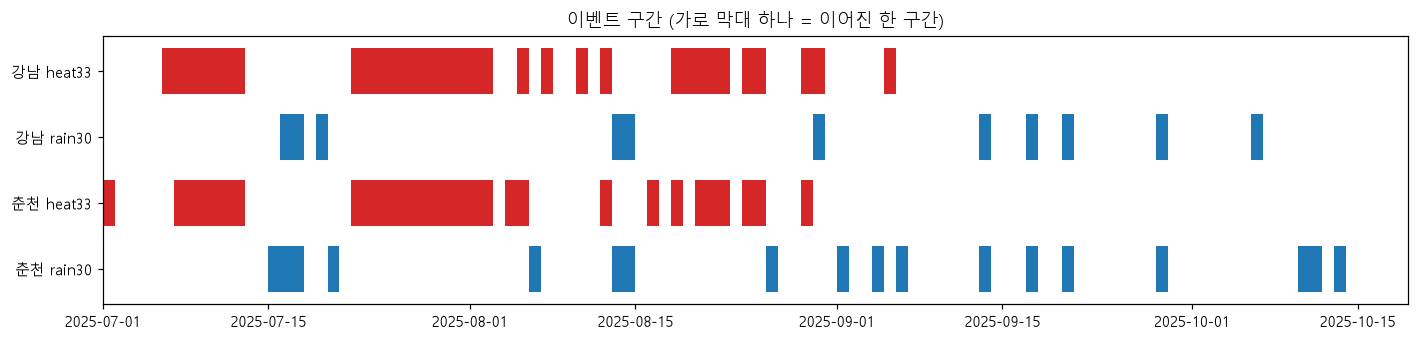

In [25]:
목록 = []
for r in ['강남', '춘천']:
    for e in ['heat33', 'rain30']:
        sp = make_spells(wx[wx['region'].eq(r)], e)
        목록.append(sp.assign(region=r, event=e))
spells = pd.concat(목록, ignore_index=True)

요약 = spells.groupby(['region', 'event']).agg(
    구간수=('spell_id', 'size'), 이벤트일수=('length_days', 'sum'),
    최장=('length_days', 'max'), 평균길이=('length_days', 'mean'))
print('전체 구간:', len(spells)); display(요약.round(2))

fig, ax = plt.subplots(figsize=(13, 3.2))
줄 = [('강남', 'heat33'), ('강남', 'rain30'), ('춘천', 'heat33'), ('춘천', 'rain30')]
for y, (r, e) in enumerate(줄):
    s = spells[(spells['region'] == r) & (spells['event'] == e)]
    ax.barh([y] * len(s), s['length_days'], left=s['start'], height=0.7,
            color='#d62728' if e == 'heat33' else '#1f77b4')
ax.set_yticks(range(len(줄))); ax.set_yticklabels([f'{r} {e}' for r, e in 줄])
ax.invert_yaxis(); ax.set_title('이벤트 구간 (가로 막대 하나 = 이어진 한 구간)')
plt.tight_layout(); plt.show()

### 6-3. 구간 사이 간격과 ±7일 창 겹침 (탐색 Q7-a)

강남 heat33: 간격 [9, 2, 1, 2, 1, 5, 1, 3, 5] | 중앙값 2일 | 7일 미만 8/9개
강남 rain30: 간격 [1, 24, 15, 13, 3, 2, 7, 7] | 중앙값 7일 | 7일 미만 3/8개
춘천 heat33: 간격 [5, 9, 1, 6, 3, 1, 1, 1, 3] | 중앙값 3일 | 7일 미만 8/9개
춘천 rain30: 간격 [2, 16, 6, 11, 5, 2, 1, 6, 3, 2, 7, 11, 1] | 중앙값 5일 | 7일 미만 9/13개


,region,event,깨끗한 구간,전체
0,강남,heat33,0,10
1,강남,rain30,2,9
2,춘천,heat33,0,10
3,춘천,rain30,0,14


간격 2일 이하를 합치면: {'강남 heat33': '10 -> 5개', '강남 rain30': '9 -> 7개', '춘천 heat33': '10 -> 6개', '춘천 rain30': '14 -> 9개'}


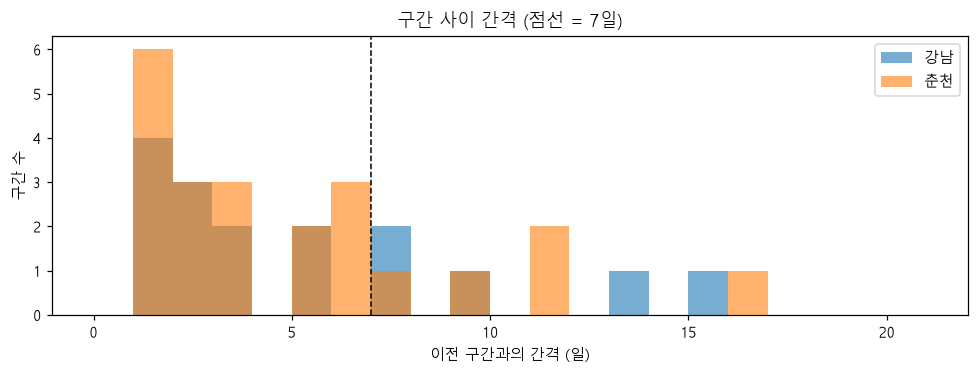

In [26]:
for (r, e), g in spells.groupby(['region', 'event']):
    간격 = g['gap_to_prev_days'].dropna().astype(int).tolist()
    print(f'{r} {e}: 간격 {간격} | 중앙값 {np.median(간격):.0f}일 | 7일 미만 {sum(1 for x in 간격 if x < 7)}/{len(간격)}개')

# t-7 ~ t+14 창이 다른 구간과 겹치지 않는 '깨끗한 구간' 세기
깨끗 = []
for (r, e), g in spells.groupby(['region', 'event']):
    g = g.sort_values('start')
    앞 = g['gap_to_prev_days'].fillna(999)
    뒤 = (g['start'].shift(-1) - g['end']).dt.days.fillna(999) - 1
    깨끗.append({'region': r, 'event': e, '깨끗한 구간': int(((앞 >= 7) & (뒤 >= 14)).sum()), '전체': len(g)})
display(pd.DataFrame(깨끗))

# 간격이 2일 이하인 구간끼리 합치면 몇 개가 되는가 (합치기 규칙 후보)
합친결과 = {}
for (r, e), g in spells.groupby(['region', 'event']):
    g = g.sort_values('start')
    새구간 = (g['gap_to_prev_days'].fillna(999) > 2).cumsum()
    합친결과[f'{r} {e}'] = f'{len(g)} -> {새구간.nunique()}개'
print('간격 2일 이하를 합치면:', 합친결과)

fig, ax = plt.subplots(figsize=(9, 3.5))
for r in ['강남', '춘천']:
    ax.hist(spells.loc[spells['region'].eq(r), 'gap_to_prev_days'].dropna(),
            bins=range(0, 22, 1), alpha=0.6, label=r, color=REGION_COLOR[r])
ax.axvline(7, ls='--', color='k', lw=1)
ax.set(xlabel='이전 구간과의 간격 (일)', ylabel='구간 수', title='구간 사이 간격 (점선 = 7일)')
ax.legend(); plt.tight_layout(); plt.show()

### 6-4. wx_events 저장

In [27]:
wx_events = spells[['region', 'event', 'spell_id', 'start', 'end', 'length_days', 'gap_to_prev_days']].copy()
wx_events['gap_to_prev_days'] = wx_events['gap_to_prev_days'].astype('Int64')   # 빈칸을 허용하는 정수형
wx_events = wx_events.sort_values(['region', 'event', 'spell_id']).reset_index(drop=True)

print('모양:', wx_events.shape, '| 이벤트별:', wx_events['event'].value_counts().to_dict(),
      '| gap 빈칸:', int(wx_events['gap_to_prev_days'].isna().sum()))
wx_events.to_parquet(OUT / 'wx_events.parquet', index=False)
display(wx_events.head(3))

모양: (43, 7) | 이벤트별: {'rain30': 23, 'heat33': 20} | gap 빈칸: 4


,region,event,spell_id,start,end,length_days,gap_to_prev_days
0,강남,heat33,1,2025-07-06,2025-07-12,7,<NA>
1,강남,heat33,2,2025-07-22,2025-08-02,12,9
2,강남,heat33,3,2025-08-05,2025-08-05,1,2


### 6장 정리
- **본 것**: 연속 구간 만들기(6-1), 구간 목록과 간트 차트(6-2), 구간 사이 간격과 창 겹침(6-3), 저장(6-4)
- **나온 것**:
  - 전체 43개 구간. 강남 heat33 10개(33일, 최장 12일), 춘천 heat33 10개(30일, 최장 12일), 호우는 강남 9개 춘천 14개로 **대부분 1~2일짜리**
  - 긴 폭염은 **7/6~7/12와 7/22~8/2 두 덩어리**뿐이고 나머지는 8월에 1~5일씩 흩어져 있다
  - 구간 사이 간격의 중앙값이 강남 2일, 춘천 3일이고, **9개 간격 중 8개가 7일 미만**이다
  - **t-7 ~ t+14 창이 깨끗한 폭염 구간은 두 지역 모두 0개**다(강남 호우만 2개)
  - 간격 2일 이하를 합치면 강남 10 → 5개, 춘천 10 → 6개로 줄어든다
- **시사점**:
  - 탐색 문서가 걱정한 **창 겹침이 사실로 확인**됐다. 05번 event study는 ① 창을 ±3일로 줄이거나 ② 구간을 합치거나 ③ 여름이 끝나는 전환 한 번만 보는 방법 중에서 골라야 한다
  - 춘천 첫 폭염 구간은 7/1 하루인데 자료가 7/1부터라 **6월부터 이어진 구간인지 알 수 없다**(왼쪽이 잘린 구간). 7월 초 구간은 해석에 조심한다

## 7. 특보 원문 파싱
기상청 특보(폭염주의보, 호우경보 등)는 **사람이 "위험하다"고 판단해서 낸 신호**이다. 관측값 기준(33℃, 30mm) 라벨과 비교하면 라벨이 적절한지 검증할 수 있다.
원문은 한 통보문 안에 여러 특보가 `(1) ... / (2) ...` 로 이어져 있어서 **쪼개기(split) -> 한 줄씩 펼치기(explode) -> 정규식으로 뽑기** 순서로 정리한다.

> 참고: 탐색 문서는 특보 파싱을 "맥락 자료"로 분류했다. 메인 질문에 꼭 필요하지는 않지만 라벨 검증과 발표 자료에 쓸모가 있다.

### 7-1. 원문 구조 살펴보기

In [28]:
display(wx_warning.head(10))
print('권역별 통보문 수'); display(wx_warning['area_group'].value_counts().head(8).to_frame().T)

print('\n원문 예시')
for s in wx_warning['effective_raw'].sample(5, random_state=0):
    print(' ', s)

SPLIT = r'\s*/\s*(?=\(\d+\))'      # ' / ' 중 바로 뒤에 (숫자)가 오는 자리
항목수 = wx_warning['effective_raw'].str.split(SPLIT, regex=True).str.len()
대상수 = wx_warning['target_raw'].str.split(SPLIT, regex=True).str.len()
print(f'\n항목 2개 이상인 통보문 {int((항목수 >= 2).sum())}개, 최대 {항목수.max()}개')
print('두 열의 항목 수가 다른 행:', int((항목수 != 대상수).sum()))
print('content_raw가 있는 행:', int(wx_warning['content_raw'].notna().sum()))

,issued_at,area_group,effective_raw,target_raw,content_raw
0,2025-07-01 10:00:00,강원특별자치도,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 강원도(동해평지. 양양평지),None
1,2025-07-01 10:00:00,전국,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 강원도(동해평지. 양양평지). 전라남도(완도). 경상북도(...,None
2,2025-07-01 10:00:00,대구·경상북도,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 경상북도(상주. 예천. 영덕. 울진평지),None
3,2025-07-01 10:00:00,전남광주통합특별시,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 전라남도(완도),None
4,2025-07-01 12:00:00,서울·인천·경기도,(1) 폭염주의보 발표 : 2025년 07월 01일 12시 00분,(1) 폭염주의보 발표 : 경기도(광명. 안산. 고양. 양주. 의정부. 파주. 의왕),None
5,2025-07-01 12:00:00,대전·세종·충청남도,(1) 폭염주의보 발표 : 2025년 07월 01일 12시 00분,(1) 폭염주의보 발표 : 충청남도(예산. 당진. 홍성),None
6,2025-07-01 12:00:00,전국,(1) 폭염주의보 발표 : 2025년 07월 01일 12시 00분,(1) 폭염주의보 발표 : 경기도(광명. 안산. 고양. 양주. 의정부. 파주. 의왕...,None
7,2025-07-01 13:25:00,서울·인천·경기도,(1) 호우주의보 발표 : 2025년 07월 01일 13시 25분,(1) 호우주의보 발표 : 경기도(용인),None
8,2025-07-01 13:25:00,전국,(1) 호우주의보 발표 : 2025년 07월 01일 13시 25분,(1) 호우주의보 발표 : 경기도(용인),None
9,2025-07-01 15:30:00,서울·인천·경기도,(1) 호우주의보 해제 : 2025년 07월 01일 15시 30분,(1) 호우주의보 해제 : 경기도(용인),None


권역별 통보문 수


area_group,전국,전남광주통합특별시,제주도,대구·경상북도,강원특별자치도,서울·인천·경기도,부산·울산·경상남도,대전·세종·충청남도
count,1608,471,408,380,360,352,320,249



원문 예시
  (1) 호우주의보 발표 : 2025년 08월 31일 16시 15분
  (1) 호우경보 변경 : 2025년 07월 19일 08시 30분 / (2) 호우주의보 변경 : 2025년 07월 19일 08시 30분
  (1) 강풍주의보 발표 : 2025년 12월 03일 06시 00분 / (2) 풍랑주의보 발표 : 2025년 12월 03일 06시 00분
  (1) 풍랑주의보 발표 : 2025년 10월 07일 02시 00분
  (1) 풍랑주의보 연장 : 2025년 10월 21일 18시 00분

항목 2개 이상인 통보문 1129개, 최대 10개
두 열의 항목 수가 다른 행: 0
content_raw가 있는 행: 1055


### 7-2. 항목 단위로 쪼개고 펼치기

In [29]:
SPLIT = r'\s*/\s*(?=\(\d+\))'      # ' / ' 중 바로 뒤에 (숫자)가 오는 자리에서만 자른다

w = wx_warning.reset_index(names='msg_id').copy()
w['eff_list'] = w['effective_raw'].str.split(SPLIT, regex=True)
w['tgt_list'] = w['target_raw'].str.split(SPLIT, regex=True)

items = (w.explode(['eff_list', 'tgt_list'])
         .rename(columns={'eff_list': 'eff_item', 'tgt_list': 'tgt_item'})
         .reset_index(drop=True))          # explode는 원래 인덱스를 남긴다. 중복 인덱스로 join하면 행이 불어난다
print(f'통보문 {len(w):,}개 -> 항목 {len(items):,}행')
display(items[['msg_id', 'issued_at', 'area_group', 'eff_item', 'tgt_item']].head(3))

통보문 4,430개 -> 항목 6,025행


,msg_id,issued_at,area_group,eff_item,tgt_item
0,0,2025-07-01 10:00:00,강원특별자치도,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 강원도(동해평지. 양양평지)
1,1,2025-07-01 10:00:00,전국,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 강원도(동해평지. 양양평지). 전라남도(완도). 경상북도(...
2,2,2025-07-01 10:00:00,대구·경상북도,(1) 폭염경보 변경 : 2025년 07월 01일 10시 00분,(1) 폭염경보 변경 : 경상북도(상주. 예천. 영덕. 울진평지)


### 7-3. 정규식으로 종류, 수준, 행위, 발효시각 뽑기

In [30]:
패턴 = (r'^\((?P<item_no>\d+)\)\s*(?P<kind>\S+?)(?P<level>주의보|경보|예비특보)'
        r'\s+(?P<action>\S+)\s*:\s*(?P<eff>\d{4}년 \d{2}월 \d{2}일 \d{2}시 \d{2}분)')
뽑기 = items['eff_item'].str.extract(패턴)
items = items.join(뽑기)
items['effective_at'] = pd.to_datetime(items['eff'], format='%Y년 %m월 %d일 %H시 %M분')
items['item_no'] = items['item_no'].astype(int)
items['target_area'] = (items['tgt_item']
                        .str.replace(r'^\(\d+\)\s*\S+\s+\S+\s*:\s*', '', regex=True).str.strip())

print('파싱 실패:', int(items['kind'].isna().sum()), '행')
display(items['kind'].value_counts().to_frame().T)
display(items['level'].value_counts().to_frame().T)
display(items['action'].value_counts().to_frame().T)
print('\nkind x (level, action)'); display(pd.crosstab(items['kind'], [items['level'], items['action']]))

지연 = (items['effective_at'] - items['issued_at']).dt.total_seconds() / 3600
print(f'발효시각 - 발표시각: 중앙값 {지연.median():.0f}시간, 최대 {지연.max():.0f}시간')

파싱 실패: 0 행


kind,호우,풍랑,강풍,폭염,대설,한파,폭풍해일,건조
count,2193,1833,876,627,222,126,101,47


level,주의보,경보,예비특보
count,5133,890,2


action,발표,해제,변경,연장
count,2723,2184,1054,64



kind x (level, action)


level  경보           예비특보  주의보              
action 발표   변경   해제   해제   발표   변경  연장   해제
kind                                       
강풍      0   32    0    0  443   32  14  355
건조      0    6    0    0   28    3   0   10
대설      0    4    0    0  116    2   0  100
폭염      0  185   40    0  188   76   0  138
폭풍해일    0    0    0    0   52    0   0   49
풍랑      0   69    0    2  889   68  50  755
한파      7    4    4    0   55    2   0   54
호우      4  421  114    0  941  150   0  563

발효시각 - 발표시각: 중앙값 0시간, 최대 11시간


### 7-4. 서울과 춘천이 원문에 어떻게 적혀 있나

In [31]:
서울부분 = items['target_area'].str.extract(r'(?:^|\. )(서울(?:\([^)]*\))?)(?=\.|$)')[0]
print('서울 표기 모양'); display(서울부분.value_counts().head(10).to_frame())

강원부분 = items['target_area'].str.extract(r'(?:^|\. )(강원도(?:\([^)]*\))?)(?=\.|$)')[0]
print('강원도 항목:', int(강원부분.notna().sum()),
      '| 괄호 없는 강원도:', int(강원부분.eq('강원도').sum()),
      '| 춘천 포함:', int(강원부분.fillna('').str.contains('춘천').sum()),
      "| '제외' 포함:", int(강원부분.fillna('').str.contains('제외').sum()))
print('\n제외가 붙은 강원도 표기:', 강원부분[강원부분.fillna('').str.contains('제외')].unique()[:5])
print('춘천이 강원도 괄호 밖에 나오는 항목:',
      int((items['target_area'].str.contains('춘천') & ~강원부분.fillna('').str.contains('춘천')).sum()))

서울 표기 모양


,count
0,
서울,48
서울(서울서남권),18
서울(서울동남권 제외),10
서울(서울서남권. 서울서북권),8
서울(서울동남권),8
서울(서울동북권. 서울서남권),8
서울(서울서북권),6
서울(서울동북권),6
서울(서울서남권 제외),4


강원도 항목: 572 | 괄호 없는 강원도: 0 | 춘천 포함: 74 | '제외' 포함: 4

제외가 붙은 강원도 표기: ['강원도(강릉평지. 동해평지. 삼척평지 제외)' '강원도(철원. 양구평지. 인제평지. 강원중부산지 제외)']
춘천이 강원도 괄호 밖에 나오는 항목: 0


### 7-5. 강남과 춘천 매칭 규칙 만들기

In [32]:
def hit(area, prov, sub):
    """해당지역 글자 area가 광역 prov의 세부 구역 sub를 포함하는가."""
    if not isinstance(area, str):
        return False
    m = re.search(r'(?:^|\. )' + prov + r'(?:\(([^)]*)\))?(?=\.|$)', area)
    if m is None:
        return False                      # 그 광역이 아예 없음
    안 = m.group(1)
    if 안 is None:
        return True                       # 괄호가 없으면 광역 전체
    if 안.rstrip().endswith('제외'):
        return sub not in 안               # '... 제외' 면 목록에 없을 때만 해당
    return sub in 안


items['hit_gangnam'] = items['target_area'].apply(lambda a: hit(a, '서울', '서울동남권'))
items['hit_chuncheon'] = items['target_area'].apply(lambda a: hit(a, '강원도', '춘천'))

print('강남 해당 항목:', int(items['hit_gangnam'].sum()), '| 춘천 해당 항목:', int(items['hit_chuncheon'].sum()))
print("'서울' 글자는 있지만 강남에 해당하지 않는 항목:",
      int((items['target_area'].str.contains('서울', na=False) & ~items['hit_gangnam']).sum()))

for 예 in ['서울(서울동남권 제외)', '서울', '서울(서울동북권. 서울동남권)', '경기도(안산. 수원 제외)']:
    print(f'  {예!r:34s} -> 강남 {hit(예, "서울", "서울동남권")}')

강남 해당 항목: 62 | 춘천 해당 항목: 78
'서울' 글자는 있지만 강남에 해당하지 않는 항목: 58
  '서울(서울동남권 제외)'                     -> 강남 False
  '서울'                               -> 강남 True
  '서울(서울동북권. 서울동남권)'                 -> 강남 True
  '경기도(안산. 수원 제외)'                   -> 강남 False


### 7-6. wx_warning_parsed 저장

In [33]:
PARSED_COLS = ['msg_id', 'item_no', 'issued_at', 'area_group', 'kind', 'level', 'action',
               'effective_at', 'target_area', 'hit_gangnam', 'hit_chuncheon']
wx_warning_parsed = items[PARSED_COLS].reset_index(drop=True)
print('모양:', wx_warning_parsed.shape)
wx_warning_parsed.to_parquet(OUT / 'wx_warning_parsed.parquet', index=False)
display(wx_warning_parsed.head(3))

모양: (6025, 11)


,msg_id,item_no,issued_at,area_group,kind,level,action,effective_at,target_area,hit_gangnam,hit_chuncheon
0,0,1,2025-07-01 10:00:00,강원특별자치도,폭염,경보,변경,2025-07-01 10:00:00,강원도(동해평지. 양양평지),False,False
1,1,1,2025-07-01 10:00:00,전국,폭염,경보,변경,2025-07-01 10:00:00,강원도(동해평지. 양양평지). 전라남도(완도). 경상북도(상주. 예천. 영덕. 울진평지),False,False
2,2,1,2025-07-01 10:00:00,대구·경상북도,폭염,경보,변경,2025-07-01 10:00:00,경상북도(상주. 예천. 영덕. 울진평지),False,False


### 7장 정리
- **본 것**: 통보문 구조(7-1), 항목 단위로 쪼개기(7-2), 정규식 파싱(7-3), 지역 표기 모양(7-4), 매칭 규칙(7-5), 저장(7-6)
- **나온 것**:
  - 통보문 4,430개 → 항목 6,025개. **파싱 실패 0건**
  - 종류는 호우 2,193, 풍랑 1,833, 강풍 876, 폭염 627 순. 수준은 주의보 5,133, 경보 890
  - **폭염경보는 "발표"가 0번이고 "변경"이 185번**이다. 항상 주의보에서 올라가는 방식으로 나온다
  - 서울은 4개 권역으로 쪼개 발표되고(강남구는 서울동남권), **'서울' 글자가 있어도 강남이 아닌 항목이 58개**다
  - 강원도는 항상 괄호가 붙고 춘천은 평지, 산지 구분 없이 '춘천' 한 단어로만 나온다
- **시사점**:
  - 특보를 지역에 붙일 때 **광역 이름만 보면 틀린다**. 괄호 안 목록과 '제외' 표기까지 읽는 매칭 규칙이 반드시 필요하다
  - 기간 계산에는 발표시각이 아니라 **발효시각(effective_at)** 을 써야 한다(최대 11시간 차이)

## 8. 특보 발효 일별 표 (wx_warning_daily)
특보는 "발표 -> (변경) -> 해제" 로 이어지는 **상태**이다. 발표된 날만 표시하면 그 뒤 며칠 동안 발효 중이었다는 정보가 빠진다.
그래서 특보 항목을 시간 순서대로 읽으면서 **"지금 발효 중인 수준"** 을 기억하는 방식(상태 기계)으로 발효 구간을 만든 뒤, 날짜별 표로 바꾼다.

### 8-1. 강남, 춘천 특보만 고르고 중복 지우기

In [34]:
KIND = {'폭염': 'heat', '호우': 'rain', '한파': 'cold'}

조각 = []
for 지역, 열 in [('강남', 'hit_gangnam'), ('춘천', 'hit_chuncheon')]:
    조각.append(wx_warning_parsed[wx_warning_parsed[열]].assign(region=지역))
지역특보 = pd.concat(조각, ignore_index=True)
지역특보 = 지역특보[지역특보['kind'].isin(KIND)].copy()
지역특보['kind_en'] = 지역특보['kind'].map(KIND)

print('중복 제거 전:', len(지역특보), '항목')
지역특보 = (지역특보.sort_values(['effective_at', 'issued_at'])
           .drop_duplicates(['region', 'kind', 'level', 'action', 'effective_at'])
           .reset_index(drop=True))
print('중복 제거 후:', len(지역특보), '항목')
display(지역특보.pivot_table(index='region', columns='kind', values='msg_id', aggfunc='size'))
display(지역특보[지역특보['kind'].eq('폭염')].groupby('region').head(1)
        [['region', 'kind', 'level', 'action', 'effective_at']])

중복 제거 전: 124 항목
중복 제거 후: 62 항목


kind,폭염,한파,호우
region,,,
강남,13,3,13
춘천,12,6,15


,region,kind,level,action,effective_at
0,강남,폭염,경보,변경,2025-07-07 10:00:00
1,춘천,폭염,경보,변경,2025-07-07 10:00:00


### 8-2. 상태 기계로 발효 구간 만들기

In [35]:
LV = {'주의보': 1, '경보': 2}
기간끝 = pd.Timestamp('2026-01-01')

구간 = []
for (지역, 종류), g in 지역특보.groupby(['region', 'kind_en']):
    g = g.sort_values('effective_at')
    상태, 시작 = 0, START
    첫 = g.iloc[0]
    if 첫['action'] == '변경':
        상태 = 2 if LV[첫['level']] == 1 else 1     # 경보로 변경됐다면 그 전은 주의보
        print(f'  시작 상태 가정: {지역} {종류} -> {"주의보" if 상태 == 1 else "경보"} (첫 항목이 변경)')
    elif 첫['action'] == '해제':
        상태 = LV[첫['level']]
        print(f'  시작 상태 가정: {지역} {종류} -> {첫["level"]} (첫 항목이 해제)')

    for _, r in g.iterrows():
        t = r['effective_at']
        if r['action'] in ('발표', '변경', '연장'):
            if 상태 != 0 and t > 시작:
                구간.append((지역, 종류, 상태, 시작, t))
            상태, 시작 = LV[r['level']], t
        elif r['action'] == '해제':
            if 상태 != 0:
                구간.append((지역, 종류, 상태, 시작, t))
                상태 = 0
            else:
                print(f'  무시한 해제: {지역} {종류} {t}')
    if 상태 != 0:
        구간.append((지역, 종류, 상태, 시작, 기간끝))

warn_spells = pd.DataFrame(구간, columns=['region', 'kind', 'level', 'start', 'end'])
warn_spells['hours'] = (warn_spells['end'] - warn_spells['start']).dt.total_seconds() / 3600

print('\n구간', len(warn_spells), '개')
display(warn_spells.pivot_table(index='region', columns='kind', values='hours', aggfunc='sum').round(0))
display(warn_spells[warn_spells['kind'].eq('heat')].head(4))

  시작 상태 가정: 강남 heat -> 주의보 (첫 항목이 변경)
  무시한 해제: 강남 rain 2025-07-19 07:30:00
  시작 상태 가정: 춘천 heat -> 주의보 (첫 항목이 변경)

구간 38 개


kind,cold,heat,rain
region,,,
강남,40.00,"1,004.00",66.00
춘천,101.00,"1,028.00",63.00


,region,kind,level,start,end,hours
2,강남,heat,1,2025-07-01 00:00:00,2025-07-07 10:00:00,154.00
3,강남,heat,2,2025-07-07 10:00:00,2025-07-13 10:00:00,144.00
4,강남,heat,1,2025-07-13 10:00:00,2025-07-13 14:00:00,4.00
5,강남,heat,1,2025-07-21 16:20:00,2025-07-24 10:00:00,65.67


### 8-3. 날짜별 표로 바꿔서 wx_warning_daily 저장

In [36]:
날짜틀 = pd.MultiIndex.from_product([pd.date_range(START, END), ['강남', '춘천']],
                                   names=['date', 'region']).to_frame(index=False)

행 = []
for _, r in 날짜틀.iterrows():
    하루시작, 하루끝 = r['date'], r['date'] + pd.Timedelta(days=1)
    값 = {'date': r['date'], 'region': r['region']}
    for 종류 in ['heat', 'rain', 'cold']:
        s = warn_spells[(warn_spells['region'] == r['region']) & (warn_spells['kind'] == 종류)]
        겹침 = s[(s['start'] < 하루끝) & (s['end'] > 하루시작)]
        시간 = ((겹침['end'].clip(upper=하루끝) - 겹침['start'].clip(lower=하루시작))
                .dt.total_seconds().sum() / 3600)
        값[f'{종류}_level'] = int(겹침['level'].max()) if len(겹침) else 0
        값[f'{종류}_on'] = len(겹침) > 0
        값[f'{종류}_hours'] = round(시간, 2)
    행.append(값)

wx_warning_daily = pd.DataFrame(행)
print('모양:', wx_warning_daily.shape)
display(wx_warning_daily.groupby('region')[['heat_on', 'rain_on', 'cold_on']].sum())
print('경보 수준인 날:', wx_warning_daily[wx_warning_daily['heat_level'].eq(2)].groupby('region').size().to_dict())
print('heat_hours >= 12 인 날:',
      wx_warning_daily[wx_warning_daily['heat_hours'] >= 12].groupby('region').size().to_dict())
wx_warning_daily.to_parquet(OUT / 'wx_warning_daily.parquet', index=False)

모양: (368, 11)


,heat_on,rain_on,cold_on
region,,,
강남,46,8,4
춘천,46,9,8


경보 수준인 날: {'강남': 19, '춘천': 19}
heat_hours >= 12 인 날: {'강남': 44, '춘천': 45}


### 8-4. 관측 라벨과 특보 교차 검증

In [37]:
검증 = wx.merge(wx_warning_daily, on=['date', 'region'])

for 라벨, 특보, 이름 in [('heat33', 'heat_on', '폭염'), ('rain30', 'rain_on', '호우'), ('cold12', 'cold_on', '한파')]:
    for r in ['강남', '춘천']:
        g = 검증[검증['region'].eq(r)]
        표 = pd.crosstab(g[라벨], g[특보])
        둘다 = 표.get(True, {}).get(True, 0)
        특보만 = 표.get(True, {}).get(False, 0)
        관측만 = 표.get(False, {}).get(True, 0)
        둘다아님 = 표.get(False, {}).get(False, 0)
        print(f'{r} {이름}: 둘 다 {둘다} / 특보만 {특보만} / 관측만 {관측만} / 둘 다 아님 {둘다아님}')
        if 관측만:
            print('   관측만:', [str(d.date()) for d in g.loc[g[라벨] & ~g[특보], 'date']])

print('\n35℃ 이상인 날 중 폭염경보 중이었던 날')
display(pd.crosstab([검증['region'], 검증['heat35']], 검증['heat_level'].eq(2)))
print('특보 발효 중인 날의 tmax 최솟값:',
      검증[검증['heat_on']].groupby('region')['tmax'].min().round(1).to_dict())

강남 폭염: 둘 다 29 / 특보만 17 / 관측만 4 / 둘 다 아님 134
   관측만: ['2025-08-07', '2025-08-10', '2025-08-12', '2025-09-05']
춘천 폭염: 둘 다 29 / 특보만 17 / 관측만 1 / 둘 다 아님 137
   관측만: ['2025-08-12']
강남 호우: 둘 다 6 / 특보만 2 / 관측만 5 / 둘 다 아님 171
   관측만: ['2025-07-19', '2025-08-30', '2025-09-20', '2025-09-28', '2025-10-06']
춘천 호우: 둘 다 8 / 특보만 1 / 관측만 10 / 둘 다 아님 165
   관측만: ['2025-07-15', '2025-08-26', '2025-09-01', '2025-09-04', '2025-09-06', '2025-09-20', '2025-09-28', '2025-10-10', '2025-10-11', '2025-10-13']
강남 한파: 둘 다 0 / 특보만 4 / 관측만 0 / 둘 다 아님 180
춘천 한파: 둘 다 3 / 특보만 5 / 관측만 0 / 둘 다 아님 176

35℃ 이상인 날 중 폭염경보 중이었던 날


heat_level     False  True 
region heat35              
강남     False     164      5
       True        1     14
춘천     False     165      8
       True        0     11

특보 발효 중인 날의 tmax 최솟값: {'강남': 30.3, '춘천': 27.1}


### 8-5. 관측 라벨과 특보를 한 그림에

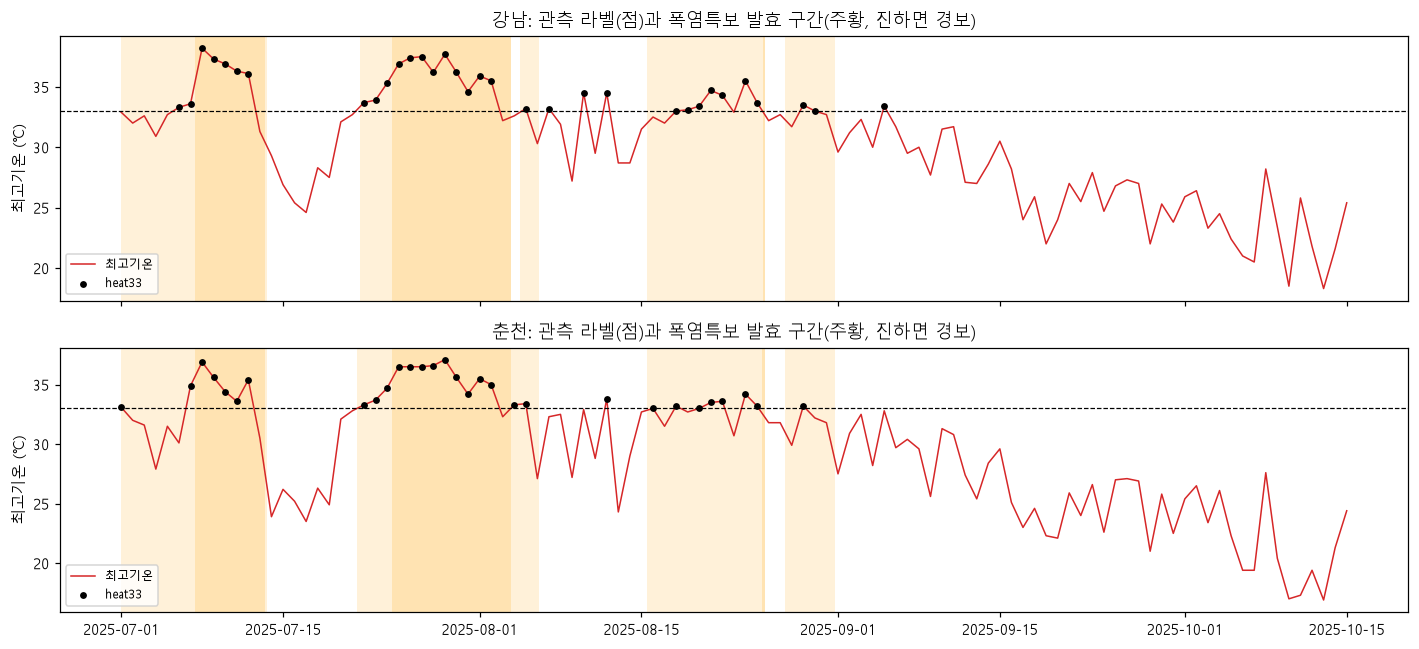

In [38]:
구간창 = (pd.Timestamp('2025-07-01'), pd.Timestamp('2025-10-15'))
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for ax, r in zip(axes, ['강남', '춘천']):
    g = wx[wx['region'].eq(r) & wx['date'].between(*구간창)].set_index('date')
    ax.plot(g.index, g['tmax'], color='#d62728', lw=1, label='최고기온')
    ax.axhline(THRESH['heat33'], ls='--', color='k', lw=0.8)
    for _, s in warn_spells[(warn_spells['region'] == r) & (warn_spells['kind'] == 'heat')].iterrows():
        ax.axvspan(max(s['start'], 구간창[0]), min(s['end'], 구간창[1]),
                   color='orange', alpha=0.15 if s['level'] == 1 else 0.3, lw=0)
    ax.scatter(g.index[g['heat33']], g.loc[g['heat33'], 'tmax'], s=12, color='k', zorder=5, label='heat33')
    ax.set(ylabel='최고기온 (℃)', title=f'{r}: 관측 라벨(점)과 폭염특보 발효 구간(주황, 진하면 경보)')
    ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

**결정**: 07번과 05번에서 특보 라벨을 어떻게 쓸지 적어 둔다.
(예: "주 라벨은 관측 기준 heat33, rain30. 특보는 강건성 확인용으로 heat_on을 대신 넣어 결과가 같은지만 본다")

- **결정**: 주 라벨은 관측 기준 `heat33`, `rain30`을 쓴다. 특보(`heat_on`, `rain_on`)는 **강건성 확인용**으로만 같은 분석을 한 번 더 돌려 결론의 방향이 바뀌는지 본다.
- **이유**: 특보는 기준이 달라 관측 라벨과 어긋난다. 폭염특보는 **체감온도** 기준이라 기온 31~32℃에도 나오고(특보만 있는 날 17일, 그날 tmax 최솟값 강남 30.3℃),
  호우특보는 **단시간 강수** 기준이라 하루 30mm가 천천히 내린 날에는 나오지 않는다(관측만 있는 날 강남 5일, 춘천 10일).
  둘 다 틀린 것이 아니라 **재는 대상이 다르다**. 카드 매출은 하루 단위라 일 기준 관측 라벨이 짝이 맞고, 특보는 "사람이 위험하다고 판단한 날"이라 해석이 달라진다.

### 8장 정리
- **본 것**: 지역 특보만 고르고 중복 제거(8-1), 상태 기계로 발효 구간 만들기(8-2), 날짜별 표(8-3), 관측 라벨과 교차 검증(8-4, 8-5)
- **나온 것**:
  - 124항목 → 중복 제거 후 62항목(같은 특보가 전국 권역과 지역 권역에 두 번 실린다). 발효 구간 38개
  - 폭염특보 발효 시간은 강남 1,004시간, 춘천 1,028시간. 호우는 66시간, 63시간으로 훨씬 짧다
  - 하루라도 폭염특보가 있던 날은 **두 지역 모두 46일**(경보 수준 19일). 관측 폭염일(33일, 30일)보다 많다
  - 교차표: 강남 폭염 둘 다 29 / **특보만 17** / 관측만 4, 춘천 둘 다 29 / 특보만 17 / 관측만 1
  - 호우는 반대로 **관측만 있는 날이 많다**(강남 5일, 춘천 10일). 35℃ 이상인 날은 거의 모두 폭염경보 중이었다(강남 15일 중 14, 춘천 11일 중 11)
- **시사점**:
  - **폭염특보는 관측 라벨보다 넓고, 호우특보는 좁다.** 기준이 체감온도와 단시간 강수로 서로 다르기 때문이다
  - 특보 시작이 관측 라벨보다 앞서는 것은 특보가 **예상**으로 나오기 때문이다. "며칠 전부터 대비했는가"를 보려면 특보가 더 맞고, "그날 실제로 더웠는가"는 관측 라벨이 맞다
  - > [추론] 7/1 이전부터 폭염주의보가 발효 중이었다(첫 항목이 '변경'). 자료가 7월부터라 그 시작일은 알 수 없어 8-2에서 7/1 0시부터로 가정했다

## 9. 전체 정리

### 9-1. 07번, 05번 노트북으로 넘길 결정 사항

| 항목 | 결정 | 근거 (몇 장) |
|---|---|---|
| 강남 대표 관측소와 채우기 규칙 (400, 108) | **400을 쓰고 믿기 어려운 날만 108로 채움** (2025년 하반기 4일) | 1장, 2-1 |
| 믿기 어려운 값 처리 (obs_hours < 24, 강수 0 모순) | ① `obs_hours < 24` → 그날 전체 변수 ② `rain == 0` & `rain_1h_max > 0` → 강수만 | 1-3 |
| 폭염 임계값 (33℃? 35℃? 07번 Q3에서 확정) | **잠정 33℃**. 강남 33일, 춘천 30일로 표본이 충분하다. 35℃는 15일, 11일로 줄어 부담 | 2-2, 5-2 |
| 열대야 라벨 사용 여부 (춘천은 5일뿐) | **강남만 사용**. 춘천은 5일이라 단독 분석하지 않고 참고로만 | 2-2, 2-3 |
| 호우 임계값 (30mm? 80mm는 1일뿐) | **30mm 사용**. 80mm는 지역별 1일뿐이라 라벨로 쓸 수 없음 | 2-2 |
| 한파 라벨 사용 여부 (춘천 3일, 강남 0일) | **사용하지 않음**. 강남 0일이라 두 지역 비교가 불가능 | 2-2 |
| 이벤트 구간 합치기 규칙 (간격 몇 일 이하면 한 구간) | **간격 2일 이하를 합치는 안**을 07번 Q7에서 검토 (강남 10 → 5개, 춘천 10 → 6개) | 6-3 |
| event study 창 길이 (±7일 가능한가) | **불가능**. 깨끗한 폭염 구간 0개. 창을 줄이거나(-3, +7) 여름 끝 전환 한 번을 보는 쪽으로 | 6-3 |
| 시간대 폭염 지표 (hours_ge33 쓸지) | **보조로만**. 주 라벨은 일 기준 heat33, 시간대 분해에서 `hours_ge33`을 참고 | 5-3, 5-4 |
| 특보 라벨 사용 여부 | **강건성 확인용**으로만 (주 라벨은 관측 기준) | 8-4 |
| 평년 편차 해석 시 강남 관측소 차이 (+0.3℃) | 강남 편차에서 **약 0.3℃는 관측소 차이**일 수 있음을 밝히고 해석 | 3-3 |

### 9-2. 더 확인할 것
- 강남 400과 108의 차이가 2019년에 계단처럼 바뀐 이유 → 기상청 지점 정보에서 관측소 이전 여부 확인 (3-3)
- 7/1 이전(6월)부터 폭염특보가 발효 중이었는데 자료가 7월부터라 첫 구간의 시작을 모른다 → 05번 event study에서 7월 초 구간은 조심 (8-2)
- 폭염특보(체감온도 기준)가 관측 heat33보다 매출을 더 잘 설명하는가 → 07번 Q3에서 비교 (8-4)
- 춘천에서 폭염일인데 33℃ 이상 시각이 0개인 6일 → 일최고가 정각 사이에 잠깐 찍힌 날. 시간대 분석에서 제외할지 판단 (5-2)
- > [추론] 춘천 폭염특보 발효 시간(1,028시간)이 참고값(1,029시간)과 1시간 다르다. 구간 경계 처리 차이로 보이며 결론에는 영향이 없다